# News Scoring — Supabase Edition

Uses `news_scoring.py` directly against the Supabase `market_data` schema.  
No API server, no JSON files.

| Table | Rows | Used for |
|---|---|---|
| `market_data.news` | 401 | Article text, title, publish_date |
| `market_data.news_embeddings` | 32 | Pre-computed 768-d vectors (gemini-001-768d) |
| `market_data.assets` | 2995 | Asset metadata (optional join) |

## 1. Setup

In [31]:
import sys, os, json, time
sys.path.insert(0, os.path.abspath('.'))

# Force reload so changes to news_scoring.py are always picked up
import importlib
if 'news_scoring' in sys.modules:
    importlib.reload(sys.modules['news_scoring'])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from news_scoring import (
    KeywordBaseline,
    HybridScorer,
    RandomProjectionLSH,
    CLEAN_ENERGY_KEYWORDS,
    INVESTMENT_THEMES,
    load_news_from_supabase,
    load_embeddings_from_supabase,
    calculate_metrics,
    evaluate_method,
    benchmark_exact_search,
    benchmark_lsh_search,
    thematic_coverage,
    calculate_theme_score,
)

load_dotenv('.env')

SUPABASE_URL = os.getenv('SUPABASE_URL', '')
SUPABASE_KEY = os.getenv('SUPABASE_KEY', '')
SCHEMA       = os.getenv('SUPABASE_SCHEMA', 'market_data')
ROW_LIMIT    = int(os.getenv('ROW_LIMIT', '401'))

print('news_scoring.py loaded OK')
print(f'Themes : {list(INVESTMENT_THEMES.keys())}')
print(f'Keywords: {len(CLEAN_ENERGY_KEYWORDS)}')


news_scoring.py loaded OK
Themes : ['Clean Energy', 'Digital Banking', 'Logistics', 'Manufacturing', 'Real Estate']
Keywords: 17


## 2. Load News from Supabase

Fetches the `news` table and normalises columns into a DataFrame.

In [32]:
df = load_news_from_supabase(
    supabase_url = SUPABASE_URL,
    supabase_key = SUPABASE_KEY,
    schema       = SCHEMA,
    limit        = ROW_LIMIT,
)

print(f'Articles loaded : {len(df)}')
print(f'Columns         : {list(df.columns)}')
print(f'Date range      : {df["publish_date"].min().date()} → {df["publish_date"].max().date()}')
print(f'Avg text length : {df["text_length"].mean():.0f} chars')
df[['news_id', 'title', 'source', 'publish_date', 'text_length']].head(5)

Articles loaded : 401
Columns         : ['id', 'news_id', 'publish_date', 'title', 'source', 'news_content', 'sentiment_score', 'source_url', 'asset_id', 'text', 'text_length', 'news_uuid']
Date range      : 2014-12-26 → 2026-05-04
Avg text length : 3596 chars


,news_id,title,source,publish_date,text_length
0,18245,FLC Group stirs back to life as founder Trinh ...,theinvestor,2026-01-27 14:29:00+00:00,7957
1,401843,Vinatex spins stronger profits on value shift,bizhub,2026-04-16 01:03:00+00:00,2543
2,401855,Việt Nam's pavilion opens at Coffee Expo Seoul...,bizhub,2026-04-15 03:16:30+00:00,3479
3,18240,"France-based Danone, owner of infamous Aptamil...",theinvestor,2026-01-27 13:56:53+00:00,1453
4,18243,VAFIE boosts investment cooperation with Arab ...,theinvestor,2026-01-27 09:27:00+00:00,5188


## 3. Load Pre-computed Embeddings from Supabase

Fetches all chunks from `news_embeddings` and **mean-pools** per article into one 768-d L2-normalised vector.  
Each stored embedding represents the full `title + news_content` of the article (not title only).

In [33]:
embeddings_map = load_embeddings_from_supabase(
    supabase_url = SUPABASE_URL,
    supabase_key = SUPABASE_KEY,
    schema       = SCHEMA,
)

print(f'Articles with embeddings : {len(embeddings_map)}')
if embeddings_map:
    sample_id = next(iter(embeddings_map))
    emb_dim   = embeddings_map[sample_id].shape[0]
    print(f'Embedding dim            : {emb_dim}  (news_row_id={sample_id})')
    EMBEDDINGS_AVAILABLE = True
else:
    emb_dim = 0
    EMBEDDINGS_AVAILABLE = False
    print('No pre-computed embeddings found')


Articles with embeddings : 798
Embedding dim            : 768  (news_row_id=6bbf614e-5633-4b14-bd3f-d86bccc17a44)


## 3.1 Embed Theme Query with Gemini

Generates a 768-d query vector using `gemini-embedding-2` (`output_dimensionality=768`) so it matches the stored article embeddings. `QUERY_EMBEDDING` is passed to `HybridScorer` to enable true semantic scoring.

In [34]:
import os
from google import genai
from google.genai import types

THEME_QUERY = 'clean energy transition renewable power generation sustainability'
QUERY_EMBEDDING = None

GOOGLE_API_KEY = os.getenv('GOOGLE_API_KEY', '')
if GOOGLE_API_KEY:
    try:
        gc = genai.Client(api_key=GOOGLE_API_KEY)
        resp = gc.models.embed_content(
            model='gemini-embedding-001',
            contents=THEME_QUERY,
            config=types.EmbedContentConfig(output_dimensionality=768),
        )
        QUERY_EMBEDDING = np.array(resp.embeddings[0].values, dtype=np.float32)
        print(f'Query embedding  dim={QUERY_EMBEDDING.shape[0]}  norm={np.linalg.norm(QUERY_EMBEDDING):.4f}')
    except Exception as e:
        print(f'Gemini embedding failed: {e}')
        print('Falling back to keyword+time only (query_embedding=None)')
else:
    print('GOOGLE_API_KEY not set — semantic scoring disabled (query_embedding=None)')
    print('Set GOOGLE_API_KEY in .env to enable full hybrid scoring')

Query embedding  dim=768  norm=0.5839


## 4. Method A — Keyword Baseline

```
score = count(keyword matches) / len(text)
```

No model required — pure text matching.

In [35]:
scorer_a = KeywordBaseline(CLEAN_ENERGY_KEYWORDS)

t0 = time.time()
df_a = scorer_a.find_relevant(df, threshold=0.0)
elapsed_a = time.time() - t0

print(f'Method A — Keyword Baseline')
print(f'{"="*55}')
print(f'Articles scored : {len(df)}')
print(f'Matched (>0)    : {len(df_a)}')
print(f'Time            : {elapsed_a*1000:.1f}ms')
df_a[['title', 'keyword_score', 'publish_date']].head(10)

Method A — Keyword Baseline
Articles scored : 401
Matched (>0)    : 74
Time            : 645.5ms


,title,keyword_score,publish_date
184,Thailand’s Super Energy earns $81 mln in Jan-S...,0.006819,2025-11-26 09:51:05+00:00
297,"VinEnergo launches rooftop solar, battery stor...",0.004360,2025-08-09 03:21:53+00:00
283,The Investor to hold green energy transition s...,0.004013,2025-10-27 08:00:00+00:00
350,Installing rooftop solar power: Why is registr...,0.003966,2025-10-11 03:23:00+00:00
169,Carlsberg Vietnam accelerates its path toward ...,0.003509,2025-11-28 04:52:51+00:00
395,Trung Nam Solar Power JSC's bank loans fully r...,0.003382,2025-09-30 10:12:47+00:00
351,ESG in Vietnamese enterprises: When sustainabl...,0.003261,2025-10-10 13:14:00+00:00
63,Thailand's WHA establishes solar power firm in...,0.003170,2026-01-12 12:46:23+00:00
114,Green Innovation Accelerator 2026 launched in ...,0.003084,2026-04-16 21:33:06+00:00
167,SP Group partners with Hoa Sen Group for Vietn...,0.002392,2025-07-23 16:42:00+00:00


In [36]:
# Score a single article
sample = df.iloc[0]
score = scorer_a.score_article(sample['text'])
print(f'Title : {sample["title"][:80]}')
print(f'Score : {score:.6f}')

# Batch scores as array
scores_a = scorer_a.score_batch(df['text'].tolist())
print(f'\nScore stats:')
print(f'  min={scores_a.min():.6f}  max={scores_a.max():.6f}  mean={scores_a.mean():.6f}')
print(f'  articles with score > 0: {(scores_a > 0).sum()}')

Title : FLC Group stirs back to life as founder Trinh Van Quyet reappears
Score : 0.000000

Score stats:
  min=0.000000  max=0.006819  mean=0.000181
  articles with score > 0: 74


## 5. Method B — Hybrid System

```
score = keyword*0.3 + semantic*0.5 + time_decay*0.2
```

Uses pre-computed Supabase embeddings when available; falls back to keyword+time only.

> **Mean pooling limitation:** Each article is represented as a single 768-d mean-pooled vector across all its chunks. This compresses a 500-word article into the same representation as a 5,000-word one; long articles may lose signal from their most-relevant passages. This is the motivation for the `ChunkRetriever` pipeline in `news_scoring.py`, which retrieves the top-scoring chunks before mean-pooling — the two techniques are complementary.

> **Embedding coverage gap:** Embeddings are available for 32 of 401 articles because the Gemini embedding job was only run on an initial batch. Methods B and C therefore evaluate on this subset. A full-corpus run would require completing the embedding pipeline.  

In [37]:
# Build embedding matrix from Supabase embeddings
embed_model = None
if EMBEDDINGS_AVAILABLE:
    ids_with_emb = [uid for uid in df['news_uuid'] if uid in embeddings_map]
    df_emb = df[df['news_uuid'].isin(ids_with_emb)].copy()
    print(f'Articles with pre-computed embeddings: {len(df_emb)}')
else:
    df_emb = df.head(50)
    print('No embeddings — using keyword+time mode on first 50 articles')

scorer_b = HybridScorer(
    keywords           = CLEAN_ENERGY_KEYWORDS,
    theme_query        = THEME_QUERY,
    keyword_weight     = 0.3,
    semantic_weight    = 0.5,
    time_weight        = 0.2,
    model              = embed_model,
    query_embedding    = QUERY_EMBEDDING,
    article_embeddings = embeddings_map,
)

sem_active = QUERY_EMBEDDING is not None
print(f'Semantic scoring active : {sem_active}')
if not sem_active:
    print('  (set GOOGLE_API_KEY and run Gemini cell to enable)')

t0 = time.time()
df_b = scorer_b.score_batch(df_emb)
elapsed_b = time.time() - t0
print(f'\nMethod B — Hybrid System')
print(f'{"="*55}')
print(f'Articles scored : {len(df_b)}')
print(f'Time            : {elapsed_b*1000:.1f}ms')
score_col = [c for c in df_b.columns if 'hybrid_score' in c or c == 'hybrid_score'][0]
df_b[['title', score_col]].sort_values(score_col, ascending=False).head(10)


Articles with pre-computed embeddings: 113
Semantic scoring active : True

Method B — Hybrid System
Articles scored : 113
Time            : 51.8ms


,title,hybrid_hybrid_score
114,Green Innovation Accelerator 2026 launched in ...,0.775898
291,Thai Connect event proposed to boost investmen...,0.757407
173,Switzerland and Việt Nam deepen partnership fo...,0.739685
131,Honda Vietnam expands biz registration to cove...,0.639036
316,Central hub begins construction of new cargo t...,0.611991
346,Việt Nam emerges as strategic hub for Japanese...,0.591527
362,AgroViet 2025 to begin in Hà Nội next week,0.577671
33,Việt Nam's eco-friendly products welcomed in H...,0.570211
296,​​​​​​​Việt Nam assumes chairmanship of ASEAN ...,0.570122
52,Việt Nam hosts first comprehensive fisheries t...,0.569329


## 6. Method C — Random Projection LSH

**Algorithm**:
1. Use pre-computed Supabase embeddings (`embeddings_map`, 768-d from `gemini-001-768d`)
2. Hash each vector via random hyperplanes into buckets
3. Embed query with `gemini-embedding-001` (same model as stored vectors)
4. Hash query and compare only within matching buckets

In [38]:
# Use pre-computed Supabase embeddings (gemini-001-768d, 768-d)
all_emb_ids  = sorted(embeddings_map.keys())
# Keep only UUIDs whose articles were loaded into df
valid_uuids  = set(df['news_uuid'].tolist())
emb_ids      = [uid for uid in all_emb_ids if uid in valid_uuids]

emb_vecs = np.stack([embeddings_map[uid] for uid in emb_ids]).astype(np.float32)
df_lsh   = df[df['news_uuid'].isin(emb_ids)].set_index('news_uuid').loc[emb_ids].reset_index()

DIM = emb_vecs.shape[1]
print(f'LSH corpus : {len(emb_ids)} articles  dim={DIM}')

lsh = RandomProjectionLSH(num_hyperplanes=12, embedding_dim=DIM)
# Store text + publish_date in metadata so query_hybrid can compute keyword & time scores
metadata = [
    {
        'title':        row['title'],
        'text':         row['text'],
        'publish_date': str(row['publish_date'].date()),
        'news_uuid':    row['news_uuid'],
    }
    for _, row in df_lsh.iterrows()
]

t0 = time.time()
lsh.add_batch(emb_vecs, metadata)
elapsed_build = time.time() - t0

stats = lsh.stats()
print(f'\nLSH index built in {elapsed_build*1000:.1f}ms')
for k, v in stats.items():
    print(f'  {k}: {v}')


LSH corpus : 113 articles  dim=768

LSH index built in 2.4ms
  num_vectors: 113
  num_buckets: 29
  avg_bucket_size: 3.896551724137931
  max_bucket_size: 46
  num_hyperplanes: 12


## 6a. LSH Internals — How Hashing Works

Each 768-d article vector is **hashed into a binary bucket key** via 12 random hyperplanes:

```
hash_bit_k = 1  if  dot(vector, hyperplane_k) > 0
           = 0  otherwise
```

The 12 bits are concatenated → a 12-character string like `"101001110010"` — that string IS the bucket key.  
Articles landing in the **same bucket** are approximate nearest neighbours and are the only ones compared at query time.


In [39]:
import textwrap

# ── 1. Show the first 3 hyperplanes (just first 8 dims for readability) ────
print('=' * 65)
print('STEP 1 — Random Hyperplanes (first 3 of 12, first 8 dims shown)')
print('=' * 65)
for i, hp in enumerate(lsh.hyperplanes[:3]):
    print(f'  H{i+1}: [{", ".join(f"{x:+.4f}" for x in hp[:8])}, ...]')

# ── 2. Hash a single article vector step-by-step ───────────────────────────
print()
print('=' * 65)
print('STEP 2 — Hashing article #0 step-by-step')
print('=' * 65)
vec0   = emb_vecs[0]
title0 = df_lsh.iloc[0]['title']
print(f'  Article : "{title0[:70]}"')
print(f'  Vector  : dim={vec0.shape[0]}, first 8 values = [{", ".join(f"{x:.4f}" for x in vec0[:8])}, ...]')
print()

projections = np.dot(lsh.hyperplanes, vec0)   # shape (12,)
bits        = (projections > 0).astype(int)
hash_key    = ''.join(map(str, bits))

print(f'  {"Plane":<8} {"dot product":>14}  {"sign":>6}  {"bit":>4}')
print(f'  {"─"*8} {"─"*14}  {"─"*6}  {"─"*4}')
for i, (proj, bit) in enumerate(zip(projections, bits)):
    sign_str = '>0 → 1' if proj > 0 else '≤0 → 0'
    print(f'  H{i+1:<7} {proj:>14.6f}  {sign_str:>6}  {bit:>4}')

print()
print(f'  Binary hash key : "{hash_key}"')
print(f'  Bucket          : lsh.hash_tables["{hash_key}"]')

# ── 3. Show all buckets with their contents ────────────────────────────────
print()
print('=' * 65)
print('STEP 3 — All Buckets in the LSH Index')
print('=' * 65)
print(f'  Total buckets : {len(lsh.hash_tables)}  (out of 2^12 = 4096 possible)')
print()

bucket_rows = []
for bkey, idxs in sorted(lsh.hash_tables.items()):
    titles = [str(lsh.metadata[i].get('title', ''))[:45] for i in idxs]
    bucket_rows.append((bkey, len(idxs), idxs, titles))

bucket_rows.sort(key=lambda x: -x[1])   # largest buckets first

print(f'  {"Bucket key":<16} {"N":>3}  Articles')
print(f'  {"─"*16} {"─"*3}  {"─"*50}')
for bkey, n, idxs, titles in bucket_rows:
    marker = ' ◀ query bucket' if bkey == hash_key else ''
    print(f'  {bkey:<16} {n:>3}  {titles[0]}{marker}')
    for t in titles[1:]:
        print(f'  {" "*16}      {t}')

# ── 4. Show exactly which articles are in the query article's bucket ───────
print()
print('=' * 65)
print(f'STEP 4 — Bucket "{hash_key}" (article #0\'s bucket)')
print('=' * 65)
bucket_members = lsh.hash_tables.get(hash_key, [])
print(f'  {len(bucket_members)} article(s) share this bucket → these are the ANN candidates\n')
for rank, idx in enumerate(bucket_members, 1):
    meta  = lsh.metadata[idx]
    vec_i = lsh.embeddings[idx]
    cosim = float(np.dot(vec0, vec_i) /
                  (np.linalg.norm(vec0) * np.linalg.norm(vec_i) + 1e-9))
    print(f'  {rank}. [cos={cosim:.4f}] {str(meta.get("title",""))[:70]}')


STEP 1 — Random Hyperplanes (first 3 of 12, first 8 dims shown)
  H1: [+0.0181, -0.0050, +0.0236, +0.0556, -0.0085, -0.0085, +0.0576, +0.0280, ...]
  H2: [-0.0228, +0.0658, +0.0257, -0.0204, +0.0230, +0.0353, +0.0226, -0.0570, ...]
  H3: [+0.0189, -0.0196, -0.0431, -0.1058, -0.0010, +0.0653, +0.0612, -0.0168, ...]

STEP 2 — Hashing article #0 step-by-step
  Article : "Ho Chi Minh City Export Furniture Fair opens as VN eyes $19B furniture"
  Vector  : dim=768, first 8 values = [-0.0024, -0.0245, -0.0226, -0.0941, -0.0028, 0.0178, 0.0103, -0.0242, ...]

  Plane       dot product    sign   bit
  ──────── ──────────────  ──────  ────
  H1            -0.030153  ≤0 → 0     0
  H2            -0.049084  ≤0 → 0     0
  H3            -0.045513  ≤0 → 0     0
  H4             0.003004  >0 → 1     1
  H5            -0.075371  ≤0 → 0     0
  H6             0.045502  >0 → 1     1
  H7             0.026034  >0 → 1     1
  H8             0.016701  >0 → 1     1
  H9             0.124095  >0 → 1     1
  

In [40]:
q_vec_c = None

if GOOGLE_API_KEY:
    try:
        resp = gc.models.embed_content(
            model='gemini-embedding-001',
            contents=THEME_QUERY,
            config=types.EmbedContentConfig(output_dimensionality=768),
        )
        q_vec_c = np.array(resp.embeddings[0].values, dtype=np.float32)
        print(f'Query embedded with gemini-embedding-001  dim={q_vec_c.shape[0]}')
    except Exception as e:
        print(f'Gemini query embedding failed: {e}')
elif QUERY_EMBEDDING is not None:
    q_vec_c = QUERY_EMBEDDING
    print('Using QUERY_EMBEDDING as fallback')

if q_vec_c is None:
    print('No query embedding available — using first article embedding as placeholder')
    q_vec_c = emb_vecs[0]

# ── Method C: LSH candidates → exact cosine → full hybrid score (like Method B) ──
t0 = time.time()
results_c = lsh.query_hybrid(
    query_vector     = q_vec_c,
    keywords         = CLEAN_ENERGY_KEYWORDS,
    top_k            = 10,
    keyword_weight   = 0.3,
    semantic_weight  = 0.5,
    time_weight      = 0.2,
)
elapsed_q = (time.time() - t0) * 1000

print(f'\nQuery   : "{THEME_QUERY[:70]}"')
print(f'Latency : {elapsed_q:.3f}ms')
print(f'\n{"Rank":<5} {"hybrid":>7} {"keyword":>8} {"semantic":>9} {"time_decay":>11}  title')
print('─' * 90)
for i, r in enumerate(results_c, 1):
    print(f'{i:<5} {r["hybrid_score"]:>7.4f} {r["keyword"]:>8.4f} {r["semantic"]:>9.4f} '
          f'{r["time_decay"]:>11.4f}  {str(r.get("title",""))[:50]}')

# Also compare with raw cosine-only query (original behaviour)
print(f'\n--- raw cosine (original lsh.query) ---')
t0 = time.time()
results_raw = lsh.query(q_vec_c, top_k=10)
elapsed_raw = (time.time() - t0) * 1000
print(f'Latency : {elapsed_raw:.3f}ms')
for i, (meta, sim) in enumerate(results_raw, 1):
    print(f'{i:2d}. [{sim:.4f}] {str(meta.get("title",""))[:80]}')


Query embedded with gemini-embedding-001  dim=768

Query   : "clean energy transition renewable power generation sustainability"
Latency : 109.122ms

Rank   hybrid  keyword  semantic  time_decay  title
──────────────────────────────────────────────────────────────────────────────────────────
1      0.7701   1.0000    0.6009      0.8484  ​​​​​​​Việt Nam assumes chairmanship of ASEAN Furn
2      0.7397   1.0000    0.6358      0.6090  Switzerland and Việt Nam deepen partnership for sh
3      0.7096   1.0000    0.5715      0.6191  Outlook for Vietnam's fuel giants BSR, Petrolimex,
4      0.6569   0.6667    0.5641      0.8744  Thai Connect event proposed to boost investment co
5      0.6390   0.6667    0.6040      0.6852  Honda Vietnam expands biz registration to cover el
6      0.6182   0.6667    0.5646      0.6796  Việt Nam to host seminar on export growth strategi
7      0.5915   0.3333    0.6023      0.9519  Việt Nam emerges as strategic hub for Japanese inv
8      0.5697   0.3333    0.

## 7. Thematic Coverage

Measures how much of the Supabase news corpus covers each investment theme.

Thematic Coverage Analysis — Supabase news corpus


,theme,coverage_score,num_keywords
0,Real Estate,0.519669,5
1,Manufacturing,0.404844,5
2,Logistics,0.321428,6
3,Clean Energy,0.128370,8
4,Digital Banking,0.021888,5


/tmp/ipykernel_1009671/4134572651.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_themes, y='theme', x='coverage_score', palette='RdYlGn')


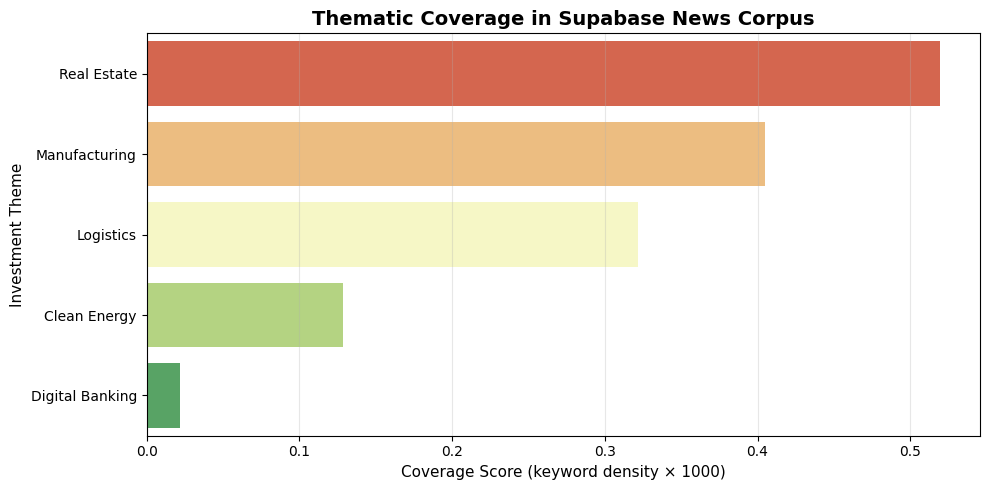

Saved: thematic_coverage_supabase.png


In [41]:
coverage = thematic_coverage(df, themes=INVESTMENT_THEMES)

df_themes = pd.DataFrame(coverage)
print('Thematic Coverage Analysis — Supabase news corpus')
print('=' * 55)
display(df_themes)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_themes, y='theme', x='coverage_score', palette='RdYlGn')
plt.title('Thematic Coverage in Supabase News Corpus', fontsize=14, fontweight='bold')
plt.xlabel('Coverage Score (keyword density × 1000)', fontsize=11)
plt.ylabel('Investment Theme', fontsize=11)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('thematic_coverage_supabase.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: thematic_coverage_supabase.png')

In [42]:
custom_theme = ['AI', 'artificial intelligence', 'machine learning', 'data center', 'semiconductor']
score = calculate_theme_score(df, custom_theme)
matched = (df['text'].str.contains('|'.join(custom_theme), case=False, na=False)).sum()
print(f'Custom Theme (AI/Tech): score={score:.4f}  matched_articles={matched}')

Custom Theme (AI/Tech): score=3.4556  matched_articles=392


## 8. Latency Benchmark — Exact vs LSH

Compare brute-force cosine similarity vs LSH bucket lookup.

Running 100 iterations each (113 articles, dim=768)...

Exact  median=0.200ms  mean=0.211ms
LSH    median=0.850ms  mean=0.862ms
Speedup: 0.23x


/tmp/ipykernel_1009671/1310810535.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=latency_df, x='method', y='latency_ms', palette='viridis')


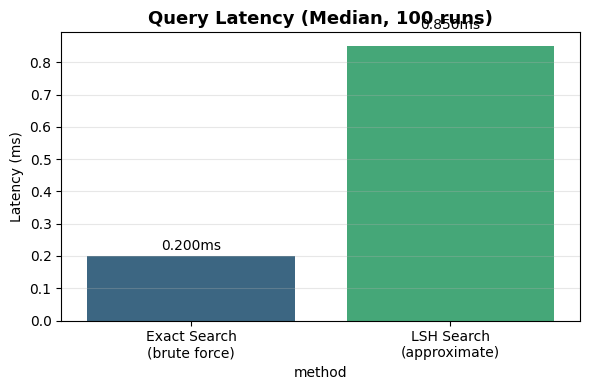

Saved: latency_supabase.png


In [43]:
NUM_RUNS = 100
print(f'Running {NUM_RUNS} iterations each ({len(emb_ids)} articles, dim={DIM})...')

exact = benchmark_exact_search(emb_vecs, q_vec_c, top_k=10, num_runs=NUM_RUNS)
lsh_b = benchmark_lsh_search(lsh, q_vec_c, top_k=10, num_runs=NUM_RUNS)

print(f'\nExact  median={exact["median_ms"]:.3f}ms  mean={exact["mean_ms"]:.3f}ms')
print(f'LSH    median={lsh_b["median_ms"]:.3f}ms  mean={lsh_b["mean_ms"]:.3f}ms')

speedup = exact['median_ms'] / lsh_b['median_ms'] if lsh_b['median_ms'] > 0 else float('inf')
print(f'Speedup: {speedup:.2f}x')

latency_df = pd.DataFrame([
    {'method': 'Exact Search\n(brute force)', 'latency_ms': exact['median_ms']},
    {'method': 'LSH Search\n(approximate)',  'latency_ms': lsh_b['median_ms']},
])
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=latency_df, x='method', y='latency_ms', palette='viridis')
for j, row in latency_df.iterrows():
    ax.text(j, row['latency_ms'] * 1.05, f"{row['latency_ms']:.3f}ms", ha='center', va='bottom')
plt.title('Query Latency (Median, 100 runs)', fontsize=13, fontweight='bold')
plt.ylabel('Latency (ms)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('latency_supabase.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: latency_supabase.png')

## 9. Evaluation — Precision, Recall, F1

Uses scores from Method A to generate synthetic ground truth, then evaluates with `calculate_metrics`.

In [44]:
eval_df = df.head(100).copy()
eval_scores = scorer_a.score_batch(eval_df['text'].tolist())

threshold   = float(np.median(eval_scores[eval_scores > 0])) if (eval_scores > 0).any() else 0.001
labels      = (eval_scores > threshold).tolist()
predictions = (eval_scores > 0.0).tolist()
print(f'Threshold       : {threshold:.6f}')
print(f'Positive labels : {sum(labels)}/{len(labels)}')

metrics = calculate_metrics(
    predictions         = predictions,
    ground_truth_labels = labels,
)
print(f'\nMethod A — Evaluation (first 100 articles)')
print(f'{"="*50}')
for k, v in metrics.items():
    print(f'  {k:<12}: {v}')

Threshold       : 0.000341
Positive labels : 8/100

Method A — Evaluation (first 100 articles)
  precision   : 0.5
  recall      : 1.0
  f1_score    : 0.6667
  accuracy    : 0.92
  tp          : 8
  fp          : 8
  fn          : 0
  tn          : 84


Best threshold : 0.000328
Best F1        : 0.9412


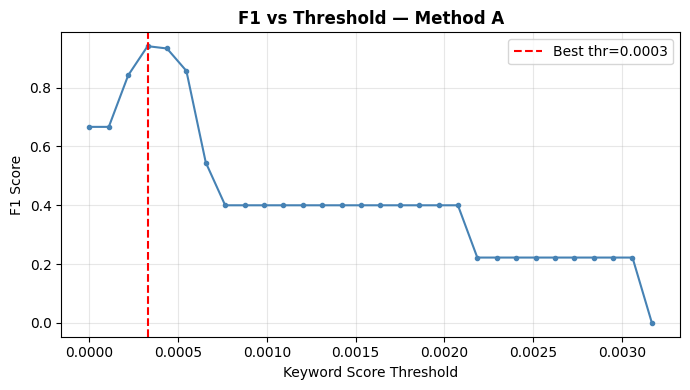

In [45]:
# Sweep thresholds to find best F1
thresholds = np.linspace(0, eval_scores.max(), 30)
f1_scores  = []
for thr in thresholds:
    preds = (eval_scores > thr).tolist()
    m = calculate_metrics(preds, labels)
    f1_scores.append(m['f1_score'])

best_thr = thresholds[np.argmax(f1_scores)]
best_f1  = max(f1_scores)
print(f'Best threshold : {best_thr:.6f}')
print(f'Best F1        : {best_f1:.4f}')

plt.figure(figsize=(7, 4))
plt.plot(thresholds, f1_scores, marker='o', markersize=3, color='steelblue')
plt.axvline(best_thr, color='red', linestyle='--', label=f'Best thr={best_thr:.4f}')
plt.title('F1 vs Threshold — Method A', fontweight='bold')
plt.xlabel('Keyword Score Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Score Distributions — Method A

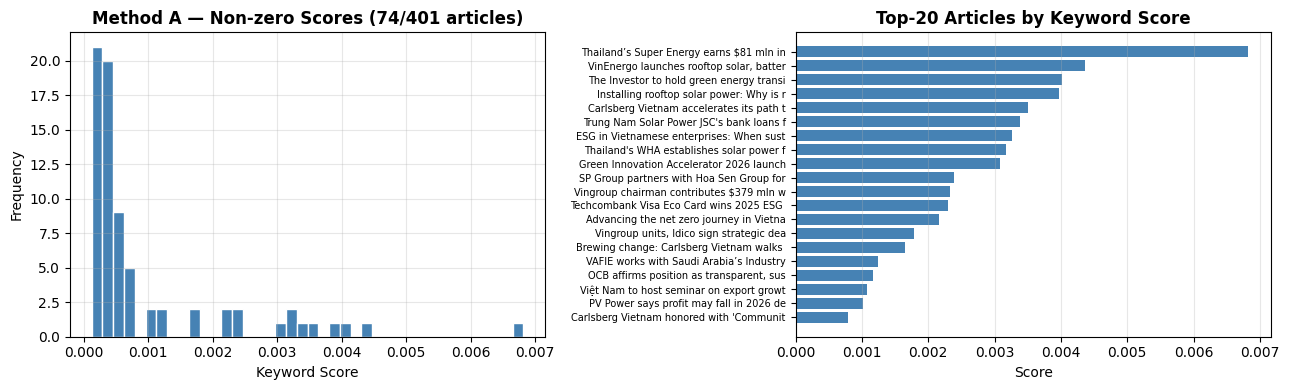

Saved: score_distribution_supabase.png


In [46]:
scores_all = scorer_a.score_batch(df['text'].tolist())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

nonzero = scores_all[scores_all > 0]
axes[0].hist(nonzero, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title(f'Method A — Non-zero Scores ({len(nonzero)}/{len(scores_all)} articles)', fontweight='bold')
axes[0].set_xlabel('Keyword Score')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

# Top-20 articles
top20_idx = np.argsort(scores_all)[::-1][:20]
top20 = df.iloc[top20_idx][['title']].copy()
top20['score'] = scores_all[top20_idx]
axes[1].barh(range(20), top20['score'].values[::-1], color='steelblue')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([t[:40] for t in top20['title'].values[::-1]], fontsize=7)
axes[1].set_title('Top-20 Articles by Keyword Score', fontweight='bold')
axes[1].set_xlabel('Score')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('score_distribution_supabase.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: score_distribution_supabase.png')

## 11. Optional — Join with Assets Table

Enrich scored articles with asset metadata from `market_data.assets`.

In [47]:
from supabase import create_client

sb  = create_client(SUPABASE_URL, SUPABASE_KEY)
sbs = sb.schema(SCHEMA)

# Fetch assets referenced by the loaded news
asset_ids = df['asset_id'].dropna().unique().tolist()[:50]
raw_assets = sbs.table('assets').select(
    'id,symbol,name_en,sector,industry,asset_class'
).in_('id', asset_ids).execute()

df_assets = pd.DataFrame(raw_assets.data)
print(f'Assets fetched: {len(df_assets)}')

# Score all articles
df_scored = df.copy()
df_scored['keyword_score'] = scorer_a.score_batch(df['text'].tolist())

if df_assets.empty or 'id' not in df_assets.columns:
    print('No asset data available — showing scored articles without asset info.')
    df_joined = df_scored
else:
    df_joined = df_scored.merge(df_assets, left_on='asset_id', right_on='id', how='left')

print(f'\nTop-10 scored articles with asset info:')
cols = ['title', 'keyword_score', 'symbol', 'sector', 'publish_date']
available = [c for c in cols if c in df_joined.columns]
df_joined.sort_values('keyword_score', ascending=False)[available].head(10)


Assets fetched: 0
No asset data available — showing scored articles without asset info.

Top-10 scored articles with asset info:


,title,keyword_score,publish_date
184,Thailand’s Super Energy earns $81 mln in Jan-S...,0.006819,2025-11-26 09:51:05+00:00
297,"VinEnergo launches rooftop solar, battery stor...",0.004360,2025-08-09 03:21:53+00:00
283,The Investor to hold green energy transition s...,0.004013,2025-10-27 08:00:00+00:00
350,Installing rooftop solar power: Why is registr...,0.003966,2025-10-11 03:23:00+00:00
169,Carlsberg Vietnam accelerates its path toward ...,0.003509,2025-11-28 04:52:51+00:00
395,Trung Nam Solar Power JSC's bank loans fully r...,0.003382,2025-09-30 10:12:47+00:00
351,ESG in Vietnamese enterprises: When sustainabl...,0.003261,2025-10-10 13:14:00+00:00
63,Thailand's WHA establishes solar power firm in...,0.003170,2026-01-12 12:46:23+00:00
114,Green Innovation Accelerator 2026 launched in ...,0.003084,2026-04-16 21:33:06+00:00
167,SP Group partners with Hoa Sen Group for Vietn...,0.002392,2025-07-23 16:42:00+00:00


## 13. Benchmark — 200 Topics

Generate `benchmark_topics.json` with 200 diverse Vietnamese business-news topics, then run Methods A / B / C across all of them.  
Results saved to `benchmark_results.json`.


In [48]:
import json
from datetime import date

BENCHMARK_TOPICS = [
    # ── Clean Energy (30) ────────────────────────────────────────────────
    {"topic_id":"T001","theme":"Clean Energy","subtopic":"Solar Power","name":"Solar panel installation Vietnam","query":"solar panel installation renewable energy Vietnam","keywords":["solar panel","solar","photovoltaic","solar installation"]},
    {"topic_id":"T002","theme":"Clean Energy","subtopic":"Wind Power","name":"Offshore wind energy development","query":"offshore wind energy development Vietnam","keywords":["offshore wind","wind power","wind energy","wind farm"]},
    {"topic_id":"T003","theme":"Clean Energy","subtopic":"Wind Power","name":"Wind turbine manufacturing","query":"wind turbine manufacturing supply chain","keywords":["wind turbine","wind power","turbine","wind energy"]},
    {"topic_id":"T004","theme":"Clean Energy","subtopic":"Hydro","name":"Hydroelectric power generation","query":"hydroelectric power dam generation capacity","keywords":["hydroelectric","hydro power","dam","water power"]},
    {"topic_id":"T005","theme":"Clean Energy","subtopic":"Green Hydrogen","name":"Green hydrogen production","query":"green hydrogen production electrolysis renewable","keywords":["green hydrogen","hydrogen","electrolysis","fuel cell"]},
    {"topic_id":"T006","theme":"Clean Energy","subtopic":"Carbon","name":"Carbon credit trading market","query":"carbon credit trading emission offset market","keywords":["carbon credit","carbon offset","emission trading","cap and trade"]},
    {"topic_id":"T007","theme":"Clean Energy","subtopic":"Solar Power","name":"Solar farm investment project","query":"solar farm investment project development","keywords":["solar farm","solar power","solar energy","PV farm"]},
    {"topic_id":"T008","theme":"Clean Energy","subtopic":"Storage","name":"Energy storage battery technology","query":"energy storage battery grid technology","keywords":["energy storage","battery","grid storage","lithium battery"]},
    {"topic_id":"T009","theme":"Clean Energy","subtopic":"Policy","name":"Clean energy transition policy","query":"clean energy transition policy government regulation","keywords":["clean energy","energy transition","renewable policy","energy policy"]},
    {"topic_id":"T010","theme":"Clean Energy","subtopic":"Carbon","name":"Carbon neutral commitment","query":"carbon neutral net zero commitment corporate","keywords":["carbon neutral","net zero","carbon footprint","decarbonisation"]},
    {"topic_id":"T011","theme":"Clean Energy","subtopic":"ESG","name":"ESG reporting requirements","query":"ESG reporting sustainability disclosure requirement","keywords":["ESG","sustainability reporting","green disclosure","ESG score"]},
    {"topic_id":"T012","theme":"Clean Energy","subtopic":"Finance","name":"Green bond issuance","query":"green bond issuance sustainable finance","keywords":["green bond","sustainable bond","climate bond","green finance"]},
    {"topic_id":"T013","theme":"Clean Energy","subtopic":"Solar Power","name":"Solar rooftop installation","query":"rooftop solar installation residential commercial","keywords":["rooftop solar","solar rooftop","net metering","solar installation"]},
    {"topic_id":"T014","theme":"Clean Energy","subtopic":"Biomass","name":"Biomass energy production","query":"biomass energy production waste biofuel","keywords":["biomass","biofuel","biogas","biomass energy"]},
    {"topic_id":"T015","theme":"Clean Energy","subtopic":"Waste Energy","name":"Waste-to-energy plant","query":"waste to energy incineration plant electricity","keywords":["waste-to-energy","incineration","waste power","bioenergy"]},
    {"topic_id":"T016","theme":"Clean Energy","subtopic":"Efficiency","name":"Energy efficiency standards","query":"energy efficiency building standard regulation","keywords":["energy efficiency","energy saving","green building","energy standard"]},
    {"topic_id":"T017","theme":"Clean Energy","subtopic":"Buildings","name":"Green building certification","query":"green building LEED EDGE certification sustainable","keywords":["green building","LEED","sustainable building","green certification"]},
    {"topic_id":"T018","theme":"Clean Energy","subtopic":"Climate","name":"Climate change adaptation infrastructure","query":"climate change adaptation flood infrastructure resilience","keywords":["climate change","adaptation","climate resilience","flood protection"]},
    {"topic_id":"T019","theme":"Clean Energy","subtopic":"Policy","name":"Net zero emissions 2050 target","query":"net zero emissions target 2050 commitment","keywords":["net zero","carbon neutral","emission target","zero carbon"]},
    {"topic_id":"T020","theme":"Clean Energy","subtopic":"Policy","name":"Renewable energy auction results","query":"renewable energy auction tender results capacity","keywords":["renewable auction","energy tender","solar auction","wind bid"]},
    {"topic_id":"T021","theme":"Clean Energy","subtopic":"Policy","name":"Feed-in-tariff solar policy","query":"feed in tariff solar power purchase agreement policy","keywords":["feed-in tariff","FIT","power purchase agreement","PPA"]},
    {"topic_id":"T022","theme":"Clean Energy","subtopic":"Trade","name":"Just energy transition partnership","query":"just energy transition JETP partnership funding","keywords":["just energy transition","JETP","energy transition fund","clean energy finance"]},
    {"topic_id":"T023","theme":"Clean Energy","subtopic":"Solar Power","name":"Photovoltaic module production","query":"photovoltaic module solar cell production manufacturing","keywords":["photovoltaic","PV module","solar cell","solar manufacturing"]},
    {"topic_id":"T024","theme":"Clean Energy","subtopic":"Climate","name":"Emission reduction 2030 targets","query":"emission reduction targets 2030 NDC climate","keywords":["emission reduction","GHG","greenhouse gas","NDC"]},
    {"topic_id":"T025","theme":"Clean Energy","subtopic":"Wind Power","name":"Onshore wind capacity expansion","query":"onshore wind capacity expansion province Vietnam","keywords":["onshore wind","wind capacity","wind power plant","wind project"]},
    {"topic_id":"T026","theme":"Clean Energy","subtopic":"Grid","name":"Power grid transmission upgrade","query":"power grid transmission line upgrade investment","keywords":["power grid","transmission","electricity grid","grid upgrade"]},
    {"topic_id":"T027","theme":"Clean Energy","subtopic":"EVs","name":"Electric vehicle charging infrastructure","query":"electric vehicle charging station infrastructure development","keywords":["EV charging","electric vehicle","charging station","EV infrastructure"]},
    {"topic_id":"T028","theme":"Clean Energy","subtopic":"EVs","name":"Electric bus fleet deployment","query":"electric bus fleet public transport deployment","keywords":["electric bus","EV bus","public transport electric","green transport"]},
    {"topic_id":"T029","theme":"Clean Energy","subtopic":"Carbon","name":"Decarbonisation industrial sector","query":"decarbonisation industry steel cement emission","keywords":["decarbonisation","industrial decarbonisation","green steel","low carbon industry"]},
    {"topic_id":"T030","theme":"Clean Energy","subtopic":"Solar Power","name":"Floating solar project development","query":"floating solar panel reservoir lake project","keywords":["floating solar","floating PV","water solar","reservoir solar"]},

    # ── Digital Banking & Fintech (30) ───────────────────────────────────
    {"topic_id":"T031","theme":"Digital Banking","subtopic":"Mobile Payment","name":"Mobile payment adoption Vietnam","query":"mobile payment adoption growth Vietnam user","keywords":["mobile payment","digital payment","e-wallet","cashless"]},
    {"topic_id":"T032","theme":"Digital Banking","subtopic":"Wallet","name":"Digital wallet Vietnam launch","query":"digital wallet launch Vietnam fintech super app","keywords":["digital wallet","e-wallet","mobile wallet","digital cash"]},
    {"topic_id":"T033","theme":"Digital Banking","subtopic":"Crypto","name":"Cryptocurrency regulation framework","query":"cryptocurrency regulation framework policy Vietnam","keywords":["cryptocurrency","crypto regulation","digital asset","bitcoin"]},
    {"topic_id":"T034","theme":"Digital Banking","subtopic":"Blockchain","name":"Blockchain technology finance","query":"blockchain technology financial services application","keywords":["blockchain","distributed ledger","DeFi","smart contract"]},
    {"topic_id":"T035","theme":"Digital Banking","subtopic":"API","name":"Open banking API ecosystem","query":"open banking API third party fintech ecosystem","keywords":["open banking","API banking","bank API","open finance"]},
    {"topic_id":"T036","theme":"Digital Banking","subtopic":"Neobank","name":"Neobank digital-only bank launch","query":"neobank digital bank online banking launch","keywords":["neobank","digital bank","challenger bank","online bank"]},
    {"topic_id":"T037","theme":"Digital Banking","subtopic":"QR","name":"QR code payment adoption","query":"QR code payment merchant retail adoption","keywords":["QR payment","QR code","contactless payment","scan pay"]},
    {"topic_id":"T038","theme":"Digital Banking","subtopic":"CBDC","name":"Central bank digital currency","query":"central bank digital currency CBDC pilot","keywords":["CBDC","digital currency","central bank digital","digital dong"]},
    {"topic_id":"T039","theme":"Digital Banking","subtopic":"Lending","name":"Peer-to-peer lending platform","query":"peer to peer lending P2P platform regulation","keywords":["P2P lending","peer lending","crowdfunding loan","online lending"]},
    {"topic_id":"T040","theme":"Digital Banking","subtopic":"Regtech","name":"Regtech compliance automation","query":"regtech regulatory compliance automation fintech","keywords":["regtech","compliance automation","KYC","AML"]},
    {"topic_id":"T041","theme":"Digital Banking","subtopic":"Insurance","name":"Insurtech digital insurance","query":"insurtech digital insurance platform innovation","keywords":["insurtech","digital insurance","insurance tech","embedded insurance"]},
    {"topic_id":"T042","theme":"Digital Banking","subtopic":"Wealth","name":"Wealthtech investment platform","query":"wealthtech digital investment platform robo-advisor","keywords":["wealthtech","digital investment","robo advisor","wealth management digital"]},
    {"topic_id":"T043","theme":"Digital Banking","subtopic":"BNPL","name":"Buy now pay later Vietnam","query":"buy now pay later BNPL retail consumption","keywords":["BNPL","buy now pay later","installment payment","deferred payment"]},
    {"topic_id":"T044","theme":"Digital Banking","subtopic":"Credit","name":"Digital credit scoring AI","query":"digital credit scoring AI alternative data","keywords":["credit scoring","alternative credit","AI credit","digital credit"]},
    {"topic_id":"T045","theme":"Digital Banking","subtopic":"Remittance","name":"Digital remittance service","query":"digital remittance overseas worker transfer fee","keywords":["remittance","money transfer","overseas transfer","digital remittance"]},
    {"topic_id":"T046","theme":"Digital Banking","subtopic":"Security","name":"Cybersecurity banking fraud","query":"cybersecurity banking fraud prevention digital attack","keywords":["cybersecurity","bank security","fraud prevention","digital fraud"]},
    {"topic_id":"T047","theme":"Digital Banking","subtopic":"AI","name":"AI fraud detection banking","query":"AI machine learning fraud detection banking transaction","keywords":["AI fraud","fraud detection","machine learning bank","transaction monitoring"]},
    {"topic_id":"T048","theme":"Digital Banking","subtopic":"Cloud","name":"Cloud banking infrastructure migration","query":"cloud banking infrastructure migration AWS Azure","keywords":["cloud banking","banking cloud","cloud migration","fintech cloud"]},
    {"topic_id":"T049","theme":"Digital Banking","subtopic":"Gateway","name":"Payment gateway integration ecommerce","query":"payment gateway integration e-commerce merchant","keywords":["payment gateway","online payment","e-commerce payment","merchant payment"]},
    {"topic_id":"T050","theme":"Digital Banking","subtopic":"Identity","name":"Digital identity eKYC verification","query":"digital identity eKYC biometric verification fintech","keywords":["eKYC","digital identity","biometric","identity verification"]},
    {"topic_id":"T051","theme":"Digital Banking","subtopic":"Stocks","name":"Stock trading mobile application","query":"stock trading mobile app retail investor brokerage","keywords":["stock trading app","trading platform","retail investor","mobile brokerage"]},
    {"topic_id":"T052","theme":"Digital Banking","subtopic":"Microfinance","name":"Microfinance digital platform","query":"microfinance digital small loan rural access","keywords":["microfinance","micro loan","financial inclusion","small credit"]},
    {"topic_id":"T053","theme":"Digital Banking","subtopic":"Cross Border","name":"Cross-border payment ASEAN","query":"cross border payment ASEAN settlement interoperability","keywords":["cross-border payment","international payment","ASEAN payment","FX transfer"]},
    {"topic_id":"T054","theme":"Digital Banking","subtopic":"License","name":"Digital banking license application","query":"digital banking license application regulator approval","keywords":["digital banking license","bank license","fintech license","digital bank approval"]},
    {"topic_id":"T055","theme":"Digital Banking","subtopic":"BaaS","name":"Banking as a service platform","query":"banking as a service BaaS embedded fintech","keywords":["banking as a service","BaaS","embedded banking","banking platform"]},
    {"topic_id":"T056","theme":"Digital Banking","subtopic":"Crypto","name":"Crypto exchange regulation compliance","query":"crypto exchange regulation compliance licensing","keywords":["crypto exchange","cryptocurrency exchange","digital asset exchange","crypto license"]},
    {"topic_id":"T057","theme":"Digital Banking","subtopic":"Invoice","name":"Invoice financing supply chain","query":"invoice financing supply chain SME working capital","keywords":["invoice financing","supply chain finance","factoring","working capital"]},
    {"topic_id":"T058","theme":"Digital Banking","subtopic":"QR","name":"Interbank QR transfer VietQR","query":"VietQR interbank QR code payment infrastructure","keywords":["VietQR","interbank transfer","bank QR","national QR"]},
    {"topic_id":"T059","theme":"Digital Banking","subtopic":"Inclusion","name":"Financial inclusion rural banking","query":"financial inclusion rural unbanked population access","keywords":["financial inclusion","unbanked","rural banking","digital inclusion"]},
    {"topic_id":"T060","theme":"Digital Banking","subtopic":"Lending","name":"SME digital lending platform","query":"SME digital lending small medium enterprise loan","keywords":["SME lending","small business loan","digital SME","SME finance"]},

    # ── Logistics & Supply Chain (25) ────────────────────────────────────
    {"topic_id":"T061","theme":"Logistics","subtopic":"Port","name":"Port expansion container capacity","query":"port expansion container capacity infrastructure","keywords":["port expansion","container port","seaport","harbor capacity"]},
    {"topic_id":"T062","theme":"Logistics","subtopic":"Cold Chain","name":"Cold chain logistics temperature","query":"cold chain logistics temperature controlled food pharma","keywords":["cold chain","refrigerated logistics","temperature controlled","cold storage"]},
    {"topic_id":"T063","theme":"Logistics","subtopic":"Last Mile","name":"Last-mile delivery urban","query":"last mile delivery urban e-commerce parcel","keywords":["last mile","last-mile delivery","urban delivery","door delivery"]},
    {"topic_id":"T064","theme":"Logistics","subtopic":"Automation","name":"Warehouse automation robotics","query":"warehouse automation robotics sortation system","keywords":["warehouse automation","automated warehouse","robot warehouse","sorting robot"]},
    {"topic_id":"T065","theme":"Logistics","subtopic":"Shipping","name":"Container shipping freight rates","query":"container shipping rate freight cost logistics","keywords":["container shipping","freight rate","shipping cost","ocean freight"]},
    {"topic_id":"T066","theme":"Logistics","subtopic":"Air Cargo","name":"Air cargo capacity Vietnam","query":"air cargo capacity airport freight Vietnam","keywords":["air cargo","air freight","cargo airline","airfreight capacity"]},
    {"topic_id":"T067","theme":"Logistics","subtopic":"E-commerce","name":"Cross-border e-commerce logistics","query":"cross border e-commerce logistics export parcel","keywords":["cross-border logistics","e-commerce shipping","international parcel","export logistics"]},
    {"topic_id":"T068","theme":"Logistics","subtopic":"Disruption","name":"Supply chain disruption resilience","query":"supply chain disruption resilience diversification risk","keywords":["supply chain disruption","supply chain risk","logistics resilience","supply disruption"]},
    {"topic_id":"T069","theme":"Logistics","subtopic":"Freight","name":"Freight forwarding Vietnam 3PL","query":"freight forwarding 3PL third party logistics Vietnam","keywords":["freight forwarding","3PL","third party logistics","freight agent"]},
    {"topic_id":"T070","theme":"Logistics","subtopic":"Park","name":"Logistics park development industrial","query":"logistics park industrial zone development invest","keywords":["logistics park","logistics center","distribution center","logistics hub"]},
    {"topic_id":"T071","theme":"Logistics","subtopic":"Rail","name":"Rail freight corridor China ASEAN","query":"rail freight corridor China ASEAN train logistics","keywords":["rail freight","cargo train","railway logistics","China rail"]},
    {"topic_id":"T072","theme":"Logistics","subtopic":"Customs","name":"Customs clearance reform trade","query":"customs clearance reform facilitation trade digital","keywords":["customs clearance","customs reform","trade facilitation","customs digital"]},
    {"topic_id":"T073","theme":"Logistics","subtopic":"Intermodal","name":"Intermodal transport network","query":"intermodal transport multimodal logistics network","keywords":["intermodal","multimodal transport","intermodal logistics","truck rail ship"]},
    {"topic_id":"T074","theme":"Logistics","subtopic":"Green","name":"Green logistics decarbonisation","query":"green logistics carbon emission transport sustainability","keywords":["green logistics","sustainable logistics","low carbon transport","emission logistics"]},
    {"topic_id":"T075","theme":"Logistics","subtopic":"Drone","name":"Drone delivery pilot program","query":"drone delivery pilot last mile autonomous","keywords":["drone delivery","UAV delivery","autonomous delivery","drone logistics"]},
    {"topic_id":"T076","theme":"Logistics","subtopic":"Fleet","name":"Fleet management telematics IoT","query":"fleet management telematics GPS IoT transport","keywords":["fleet management","telematics","GPS tracking","vehicle tracking"]},
    {"topic_id":"T077","theme":"Logistics","subtopic":"Food","name":"Food supply chain traceability","query":"food supply chain traceability blockchain safety","keywords":["food supply chain","food traceability","food safety","supply chain transparency"]},
    {"topic_id":"T078","theme":"Logistics","subtopic":"Pharma","name":"Pharmaceutical supply chain logistics","query":"pharmaceutical supply chain GDP cold chain medicine","keywords":["pharma logistics","medicine supply","pharmaceutical distribution","medical logistics"]},
    {"topic_id":"T079","theme":"Logistics","subtopic":"Reverse","name":"Reverse logistics recycling return","query":"reverse logistics return management recycling circular","keywords":["reverse logistics","returns management","recycling logistics","circular logistics"]},
    {"topic_id":"T080","theme":"Logistics","subtopic":"Smart","name":"Smart logistics IoT sensor","query":"smart logistics IoT sensor real time tracking","keywords":["smart logistics","IoT logistics","intelligent logistics","connected supply chain"]},
    {"topic_id":"T081","theme":"Logistics","subtopic":"Inland","name":"Inland waterway freight transport","query":"inland waterway river freight barge transport","keywords":["inland waterway","river logistics","barge transport","water freight"]},
    {"topic_id":"T082","theme":"Logistics","subtopic":"Bonded","name":"Bonded warehouse free trade zone","query":"bonded warehouse free trade zone customs exempt","keywords":["bonded warehouse","free trade zone","customs bonded","FTZ logistics"]},
    {"topic_id":"T083","theme":"Logistics","subtopic":"Express","name":"Express delivery parcel growth","query":"express delivery parcel service e-commerce growth","keywords":["express delivery","parcel delivery","courier service","express logistics"]},
    {"topic_id":"T084","theme":"Logistics","subtopic":"Border","name":"Border gate cargo congestion","query":"border gate cargo congestion clearance delay","keywords":["border gate","border crossing","cargo delay","customs congestion"]},
    {"topic_id":"T085","theme":"Logistics","subtopic":"Digital","name":"Digital freight platform marketplace","query":"digital freight platform marketplace load matching","keywords":["digital freight","freight platform","load matching","truck marketplace"]},

    # ── Manufacturing & Industry (25) ────────────────────────────────────
    {"topic_id":"T086","theme":"Manufacturing","subtopic":"FDI","name":"FDI electronics manufacturing Vietnam","query":"FDI electronics manufacturing investment Vietnam factory","keywords":["FDI manufacturing","electronics factory","foreign investment manufacturing","tech factory"]},
    {"topic_id":"T087","theme":"Manufacturing","subtopic":"Semiconductor","name":"Semiconductor chip factory Vietnam","query":"semiconductor chip factory investment Vietnam assembly","keywords":["semiconductor","chip factory","electronics assembly","IC manufacturing"]},
    {"topic_id":"T088","theme":"Manufacturing","subtopic":"Textile","name":"Textile garment export order","query":"textile garment export order Vietnam apparel","keywords":["textile","garment export","apparel","fabric manufacturing"]},
    {"topic_id":"T089","theme":"Manufacturing","subtopic":"Steel","name":"Steel production capacity Vietnam","query":"steel production capacity Vietnam Hoa Phat hot rolled","keywords":["steel","steel production","steel mill","hot rolled coil"]},
    {"topic_id":"T090","theme":"Manufacturing","subtopic":"Auto","name":"Automobile assembly plant Vietnam","query":"automobile assembly plant car production Vietnam","keywords":["automobile","car assembly","auto plant","vehicle manufacturing"]},
    {"topic_id":"T091","theme":"Manufacturing","subtopic":"Pharma","name":"Pharmaceutical manufacturing GMP","query":"pharmaceutical manufacturing GMP standard Vietnam","keywords":["pharmaceutical manufacturing","drug production","GMP","medicine factory"]},
    {"topic_id":"T092","theme":"Manufacturing","subtopic":"Food Processing","name":"Food processing industry growth","query":"food processing industry investment Vietnam export","keywords":["food processing","food manufacturing","food industry","processed food"]},
    {"topic_id":"T093","theme":"Manufacturing","subtopic":"Furniture","name":"Furniture export market orders","query":"furniture export market Vietnam wood order","keywords":["furniture export","furniture manufacturing","wood furniture","interior furniture"]},
    {"topic_id":"T094","theme":"Manufacturing","subtopic":"Chemical","name":"Chemical plant investment","query":"chemical plant investment petrochemical Vietnam","keywords":["chemical plant","petrochemical","chemical factory","chemical industry"]},
    {"topic_id":"T095","theme":"Manufacturing","subtopic":"Industrial Zone","name":"Industrial zone expansion land","query":"industrial zone expansion land lease investment","keywords":["industrial zone","IZ expansion","industrial park","factory land"]},
    {"topic_id":"T096","theme":"Manufacturing","subtopic":"Automation","name":"Robot automation factory upgrade","query":"robot automation factory production upgrade Industry 4.0","keywords":["robot automation","factory automation","Industry 4.0","automated factory"]},
    {"topic_id":"T097","theme":"Manufacturing","subtopic":"Quality","name":"Quality control ISO certification","query":"quality control ISO 9001 certification factory standard","keywords":["quality control","ISO certification","quality standard","production quality"]},
    {"topic_id":"T098","theme":"Manufacturing","subtopic":"Plastics","name":"Plastics recycling factory","query":"plastics recycling factory circular economy Vietnam","keywords":["plastics recycling","plastic factory","recycled plastic","circular plastic"]},
    {"topic_id":"T099","theme":"Manufacturing","subtopic":"Medical","name":"Medical device production Vietnam","query":"medical device production Vietnam export regulation","keywords":["medical device","healthcare manufacturing","medical production","hospical equipment"]},
    {"topic_id":"T100","theme":"Manufacturing","subtopic":"Battery","name":"Battery EV manufacturing plant","query":"battery manufacturing EV lithium ion plant Vietnam","keywords":["battery manufacturing","EV battery","lithium battery factory","energy storage production"]},
    {"topic_id":"T101","theme":"Manufacturing","subtopic":"Footwear","name":"Footwear shoe export production","query":"footwear shoe export order Vietnam production","keywords":["footwear","shoe export","footwear manufacturing","shoe production"]},
    {"topic_id":"T102","theme":"Manufacturing","subtopic":"Paper","name":"Paper mill pulp expansion","query":"paper mill pulp production expansion Vietnam","keywords":["paper mill","paper production","pulp factory","paper industry"]},
    {"topic_id":"T103","theme":"Manufacturing","subtopic":"Cement","name":"Cement production overcapacity","query":"cement production overcapacity price market Vietnam","keywords":["cement","cement production","concrete","cement industry"]},
    {"topic_id":"T104","theme":"Manufacturing","subtopic":"Electronics","name":"Printed circuit board PCB","query":"printed circuit board PCB production Vietnam","keywords":["PCB","printed circuit board","electronics component","circuit manufacturing"]},
    {"topic_id":"T105","theme":"Manufacturing","subtopic":"Aluminum","name":"Aluminum smelting production","query":"aluminum smelting production factory Vietnam","keywords":["aluminum","aluminium smelting","aluminum production","metal factory"]},
    {"topic_id":"T106","theme":"Manufacturing","subtopic":"Tire","name":"Tire rubber manufacturing","query":"tire rubber manufacturing Vietnam export factory","keywords":["tire manufacturing","rubber factory","tyre production","rubber tire"]},
    {"topic_id":"T107","theme":"Manufacturing","subtopic":"Packaging","name":"Packaging industry growth","query":"packaging industry corrugated carton plastic growth","keywords":["packaging","corrugated box","packaging industry","carton factory"]},
    {"topic_id":"T108","theme":"Manufacturing","subtopic":"Defense","name":"Defense industry localization","query":"defense industry localization domestic production","keywords":["defense manufacturing","defense industry","military production","localization defense"]},
    {"topic_id":"T109","theme":"Manufacturing","subtopic":"Aerospace","name":"Aerospace component manufacturing","query":"aerospace component manufacturing precision Vietnam","keywords":["aerospace manufacturing","aviation parts","aircraft component","aerospace supplier"]},
    {"topic_id":"T110","theme":"Manufacturing","subtopic":"Machinery","name":"Engineering machinery equipment import","query":"engineering machinery equipment import Vietnam factory","keywords":["machinery import","industrial equipment","factory machine","engineering machinery"]},

    # ── Real Estate (25) ─────────────────────────────────────────────────
    {"topic_id":"T111","theme":"Real Estate","subtopic":"Residential","name":"Condominium project HCMC Hanoi","query":"condominium apartment project HCMC Hanoi residential","keywords":["condominium","apartment","residential project","housing complex"]},
    {"topic_id":"T112","theme":"Real Estate","subtopic":"Industrial","name":"Industrial park land lease price","query":"industrial park land lease price rental Vietnam","keywords":["industrial park","industrial land","factory rental","industrial real estate"]},
    {"topic_id":"T113","theme":"Real Estate","subtopic":"Office","name":"Office building vacancy rate","query":"office building vacancy rate grade A HCMC","keywords":["office building","office vacancy","commercial office","grade A office"]},
    {"topic_id":"T114","theme":"Real Estate","subtopic":"Retail","name":"Shopping mall retail development","query":"shopping mall retail center development tenant","keywords":["shopping mall","retail center","commercial real estate","mall development"]},
    {"topic_id":"T115","theme":"Real Estate","subtopic":"Social","name":"Social affordable housing policy","query":"social housing affordable policy government subsidy","keywords":["social housing","affordable housing","low cost housing","housing policy"]},
    {"topic_id":"T116","theme":"Real Estate","subtopic":"Land","name":"Land use right transfer certificate","query":"land use right transfer pink book certificate","keywords":["land use right","land transfer","land certificate","pink book"]},
    {"topic_id":"T117","theme":"Real Estate","subtopic":"Resort","name":"Resort villa tourism real estate","query":"resort villa tourism coastal real estate investment","keywords":["resort villa","tourism real estate","coastal property","vacation home"]},
    {"topic_id":"T118","theme":"Real Estate","subtopic":"M&A","name":"Real estate M&A deal acquisition","query":"real estate M&A deal acquisition merger developer","keywords":["real estate M&A","property acquisition","developer merger","real estate deal"]},
    {"topic_id":"T119","theme":"Real Estate","subtopic":"REIT","name":"Real estate investment trust REIT","query":"real estate investment trust REIT fund Vietnam","keywords":["REIT","real estate fund","property investment trust","real estate investment"]},
    {"topic_id":"T120","theme":"Real Estate","subtopic":"Urban","name":"Urban development master plan","query":"urban development master plan city expansion zone","keywords":["urban development","city planning","master plan","urban expansion"]},
    {"topic_id":"T121","theme":"Real Estate","subtopic":"Land Bank","name":"Land bank accumulation developer","query":"land bank acquisition developer strategic reserve","keywords":["land bank","land acquisition","property developer","land reserve"]},
    {"topic_id":"T122","theme":"Real Estate","subtopic":"Bond","name":"Real estate bond issuance","query":"real estate corporate bond issuance refinancing","keywords":["real estate bond","property bond","developer bond","corporate bond real estate"]},
    {"topic_id":"T123","theme":"Real Estate","subtopic":"Social","name":"Affordable housing shortage gap","query":"affordable housing shortage demand supply gap Vietnam","keywords":["affordable housing","housing shortage","housing gap","low income housing"]},
    {"topic_id":"T124","theme":"Real Estate","subtopic":"Smart City","name":"Smart city digital infrastructure","query":"smart city IoT infrastructure digital government Vietnam","keywords":["smart city","digital city","city infrastructure","smart urban"]},
    {"topic_id":"T125","theme":"Real Estate","subtopic":"Commercial","name":"Commercial real estate outlook","query":"commercial real estate outlook demand office retail","keywords":["commercial real estate","office market","retail property","commercial property"]},
    {"topic_id":"T126","theme":"Real Estate","subtopic":"Policy","name":"Real estate law amendment","query":"real estate law land law amendment regulation","keywords":["real estate law","land law","property regulation","housing law"]},
    {"topic_id":"T127","theme":"Real Estate","subtopic":"Mortgage","name":"Home buyer mortgage rate decrease","query":"home mortgage rate bank loan housing buyer","keywords":["mortgage","home loan","housing loan","mortgage rate"]},
    {"topic_id":"T128","theme":"Real Estate","subtopic":"Luxury","name":"Luxury high-end apartment project","query":"luxury high-end apartment villa premium residential","keywords":["luxury apartment","high end property","premium real estate","luxury residential"]},
    {"topic_id":"T129","theme":"Real Estate","subtopic":"Industrial","name":"Industrial real estate FDI demand","query":"industrial real estate demand FDI factory tenant","keywords":["industrial real estate","factory rental","industrial tenant","manufacturing property"]},
    {"topic_id":"T130","theme":"Real Estate","subtopic":"Tourism","name":"Tourism hospitality hotel recovery","query":"tourism hotel hospitality recovery occupancy rate","keywords":["hotel real estate","hospitality property","tourism real estate","hotel occupancy"]},
    {"topic_id":"T131","theme":"Real Estate","subtopic":"Market","name":"Real estate market correction","query":"real estate market correction price decline liquidity","keywords":["real estate market","property market","house price","real estate correction"]},
    {"topic_id":"T132","theme":"Real Estate","subtopic":"Auction","name":"Land auction state bid result","query":"land auction state bid result price record","keywords":["land auction","property auction","state auction","auction result"]},
    {"topic_id":"T133","theme":"Real Estate","subtopic":"Foreign","name":"Foreign ownership property Vietnam","query":"foreign ownership house apartment Vietnam restriction","keywords":["foreign ownership","foreigner property","expat housing","foreign buyer"]},
    {"topic_id":"T134","theme":"Real Estate","subtopic":"Green","name":"Green building sustainable development","query":"green building development EDGE LEED sustainable property","keywords":["green building","sustainable building","eco building","LEED property"]},
    {"topic_id":"T135","theme":"Real Estate","subtopic":"Social","name":"Worker housing near industrial zone","query":"worker housing accommodation near industrial zone factory","keywords":["worker housing","factory accommodation","industrial zone housing","social housing worker"]},

    # ── Stock Market & Finance (20) ───────────────────────────────────────
    {"topic_id":"T136","theme":"Finance","subtopic":"Index","name":"VN-Index stock market performance","query":"VN-Index stock market performance trading volume","keywords":["VN-Index","stock market","HoSE","stock exchange"]},
    {"topic_id":"T137","theme":"Finance","subtopic":"IPO","name":"IPO listing stock exchange","query":"IPO listing initial public offering stock exchange","keywords":["IPO","stock listing","public offering","share listing"]},
    {"topic_id":"T138","theme":"Finance","subtopic":"Foreign","name":"Foreign investor net buying selling","query":"foreign investor net buying selling Vietnam equities","keywords":["foreign investor","net buying","foreign flow","foreign selling"]},
    {"topic_id":"T139","theme":"Finance","subtopic":"Dividend","name":"Dividend yield stock portfolio","query":"dividend yield stock portfolio high payout ratio","keywords":["dividend","dividend yield","payout ratio","income stock"]},
    {"topic_id":"T140","theme":"Finance","subtopic":"Bond","name":"Corporate bond default risk","query":"corporate bond default risk maturity payment delay","keywords":["corporate bond","bond default","debt maturity","bond risk"]},
    {"topic_id":"T141","theme":"Finance","subtopic":"Index","name":"MSCI upgrade emerging market","query":"MSCI upgrade emerging market Vietnam stock classification","keywords":["MSCI","market upgrade","emerging market","FTSE upgrade"]},
    {"topic_id":"T142","theme":"Finance","subtopic":"M&A","name":"Merger acquisition deal Vietnam","query":"merger acquisition M&A deal corporate Vietnam","keywords":["M&A","merger","acquisition","corporate deal"]},
    {"topic_id":"T143","theme":"Finance","subtopic":"Capital","name":"Equity capital raise rights issue","query":"equity capital raise rights issue secondary offering","keywords":["capital raise","rights issue","share offering","equity issuance"]},
    {"topic_id":"T144","theme":"Finance","subtopic":"Earnings","name":"Quarterly earnings profit results","query":"quarterly earnings profit result company outlook","keywords":["earnings","profit result","quarterly result","EPS"]},
    {"topic_id":"T145","theme":"Finance","subtopic":"Regulation","name":"Securities regulation shortsale","query":"securities regulation short selling rule enforcement","keywords":["securities regulation","short selling","market regulation","stock rule"]},
    {"topic_id":"T146","theme":"Finance","subtopic":"ETF","name":"ETF fund flow Vietnam","query":"ETF fund flow Vietnam equity passive index","keywords":["ETF","fund flow","passive fund","index fund"]},
    {"topic_id":"T147","theme":"Finance","subtopic":"Derivatives","name":"Derivatives futures options market","query":"derivatives futures options market Vietnam trading","keywords":["derivatives","futures","options trading","covered warrant"]},
    {"topic_id":"T148","theme":"Finance","subtopic":"Credit","name":"Credit rating agency downgrade","query":"credit rating agency downgrade sovereign corporate","keywords":["credit rating","rating downgrade","Moody's","S&P rating"]},
    {"topic_id":"T149","theme":"Finance","subtopic":"PE","name":"Private equity investment Vietnam","query":"private equity fund investment Vietnam portfolio","keywords":["private equity","PE fund","PE investment","private capital"]},
    {"topic_id":"T150","theme":"Finance","subtopic":"VC","name":"Venture capital startup funding","query":"venture capital startup funding round Series A B","keywords":["venture capital","VC funding","startup investment","Series funding"]},
    {"topic_id":"T151","theme":"Finance","subtopic":"Macro","name":"Interest rate monetary policy SBV","query":"interest rate monetary policy State Bank Vietnam","keywords":["interest rate","monetary policy","central bank","SBV rate"]},
    {"topic_id":"T152","theme":"Finance","subtopic":"Macro","name":"Exchange rate VND USD depreciation","query":"exchange rate VND USD depreciation appreciation forex","keywords":["exchange rate","VND USD","forex","currency rate"]},
    {"topic_id":"T153","theme":"Finance","subtopic":"Macro","name":"Inflation CPI consumer price","query":"inflation consumer price CPI Vietnam monthly","keywords":["inflation","CPI","consumer price","price index"]},
    {"topic_id":"T154","theme":"Finance","subtopic":"Macro","name":"GDP growth economic forecast","query":"GDP growth economic forecast Vietnam quarter year","keywords":["GDP growth","economic growth","GDP forecast","economic outlook"]},
    {"topic_id":"T155","theme":"Finance","subtopic":"Banking","name":"Non-performing loan NPL bank","query":"non performing loan NPL bank ratio provision","keywords":["NPL","non performing loan","bad debt","loan provision"]},

    # ── Agriculture & Food (15) ──────────────────────────────────────────
    {"topic_id":"T156","theme":"Agriculture","subtopic":"Rice","name":"Rice export volume record","query":"rice export record volume Vietnam market","keywords":["rice export","rice production","rice market","Mekong rice"]},
    {"topic_id":"T157","theme":"Agriculture","subtopic":"Aquaculture","name":"Shrimp aquaculture Vietnam export","query":"shrimp aquaculture export Vietnam seafood","keywords":["shrimp","aquaculture","shrimp export","seafood farming"]},
    {"topic_id":"T158","theme":"Agriculture","subtopic":"Coffee","name":"Coffee arabica production export","query":"coffee arabica robusta production export Vietnam","keywords":["coffee export","coffee production","arabica","robusta coffee"]},
    {"topic_id":"T159","theme":"Agriculture","subtopic":"Fish","name":"Pangasius catfish export market","query":"pangasius catfish export market Vietnam Mekong","keywords":["pangasius","catfish export","tra fish","Mekong fish"]},
    {"topic_id":"T160","theme":"Agriculture","subtopic":"Fruit","name":"Fruit vegetable export demand","query":"fruit vegetable export demand Vietnam tropical","keywords":["fruit export","vegetable export","tropical fruit","agri export"]},
    {"topic_id":"T161","theme":"Agriculture","subtopic":"Organic","name":"Organic farming certification market","query":"organic farming certification sustainable agriculture market","keywords":["organic farming","organic certification","organic food","sustainable agriculture"]},
    {"topic_id":"T162","theme":"Agriculture","subtopic":"AgriTech","name":"Agritech precision farming IoT","query":"agritech precision farming IoT drone technology","keywords":["agritech","precision farming","smart agriculture","farm technology"]},
    {"topic_id":"T163","theme":"Agriculture","subtopic":"Policy","name":"Agriculture subsidy government policy","query":"agriculture subsidy support policy government farmer","keywords":["agriculture subsidy","farm support","agri policy","farmer support"]},
    {"topic_id":"T164","theme":"Agriculture","subtopic":"Fishery","name":"Fishery IUU regulation compliance","query":"fishery IUU regulation yellow card compliance export","keywords":["fishery","IUU fishing","fishery regulation","fish export compliance"]},
    {"topic_id":"T165","theme":"Agriculture","subtopic":"Biofuel","name":"Sugarcane ethanol biofuel","query":"sugarcane ethanol biofuel production blend mandate","keywords":["sugarcane","ethanol","biofuel","sugar ethanol"]},
    {"topic_id":"T166","theme":"Agriculture","subtopic":"Rubber","name":"Natural rubber latex export","query":"natural rubber latex export Vietnam price market","keywords":["natural rubber","latex","rubber export","rubber price"]},
    {"topic_id":"T167","theme":"Agriculture","subtopic":"Spice","name":"Pepper spice export price","query":"pepper black spice export price market Vietnam","keywords":["black pepper","spice export","pepper market","peppercorn"]},
    {"topic_id":"T168","theme":"Agriculture","subtopic":"Nut","name":"Cashew nut processing export","query":"cashew nut processing export Vietnam market","keywords":["cashew","cashew nut","nut export","cashew processing"]},
    {"topic_id":"T169","theme":"Agriculture","subtopic":"Feed","name":"Animal feed import soybean","query":"animal feed import soybean corn livestock Vietnam","keywords":["animal feed","livestock feed","soybean import","feed cost"]},
    {"topic_id":"T170","theme":"Agriculture","subtopic":"Safety","name":"Food safety standard certification","query":"food safety standard certification HACCP export market","keywords":["food safety","food standard","HACCP","food certification"]},

    # ── Technology & Innovation (15) ─────────────────────────────────────
    {"topic_id":"T171","theme":"Technology","subtopic":"AI","name":"AI startup Vietnam funding","query":"AI startup Vietnam artificial intelligence funding investment","keywords":["AI startup","artificial intelligence","AI investment","AI Vietnam"]},
    {"topic_id":"T172","theme":"Technology","subtopic":"Data Center","name":"Data center construction cloud","query":"data center construction cloud investment Vietnam","keywords":["data center","cloud computing","server farm","hyperscale"]},
    {"topic_id":"T173","theme":"Technology","subtopic":"5G","name":"5G network rollout coverage","query":"5G network commercial rollout coverage speed","keywords":["5G","5G network","fifth generation","mobile 5G"]},
    {"topic_id":"T174","theme":"Technology","subtopic":"Cloud","name":"Cloud computing enterprise adoption","query":"cloud computing enterprise adoption migration SaaS","keywords":["cloud computing","cloud adoption","SaaS","enterprise cloud"]},
    {"topic_id":"T175","theme":"Technology","subtopic":"Cyber","name":"Cybersecurity data privacy regulation","query":"cybersecurity data privacy regulation compliance law","keywords":["cybersecurity","data privacy","data protection","cyber law"]},
    {"topic_id":"T176","theme":"Technology","subtopic":"Semiconductor","name":"Semiconductor chip design Vietnam","query":"semiconductor chip design EDA tools fabless Vietnam","keywords":["semiconductor design","chip design","fabless","IC design"]},
    {"topic_id":"T177","theme":"Technology","subtopic":"E-commerce","name":"E-commerce platform growth GMV","query":"e-commerce platform GMV growth market share Vietnam","keywords":["e-commerce","online shopping","marketplace","GMV ecommerce"]},
    {"topic_id":"T178","theme":"Technology","subtopic":"Digital Transformation","name":"Enterprise digital transformation","query":"enterprise digital transformation ERP CRM automation","keywords":["digital transformation","enterprise IT","ERP","digitalization"]},
    {"topic_id":"T179","theme":"Technology","subtopic":"Tech Park","name":"Tech innovation park zone","query":"technology innovation park startup ecosystem hub","keywords":["tech park","innovation hub","startup ecosystem","technology zone"]},
    {"topic_id":"T180","theme":"Technology","subtopic":"EV","name":"Electric vehicle technology Vietnam","query":"electric vehicle technology Vietnam VinFast EV market","keywords":["electric vehicle","EV","VinFast","EV technology"]},
    {"topic_id":"T181","theme":"Technology","subtopic":"Autonomous","name":"Autonomous vehicle testing pilot","query":"autonomous vehicle self driving test pilot road","keywords":["autonomous vehicle","self driving car","AV test","driverless"]},
    {"topic_id":"T182","theme":"Technology","subtopic":"Biotech","name":"Biotechnology startup genomics","query":"biotechnology startup genomics healthcare innovation","keywords":["biotechnology","biotech startup","genomics","life science"]},
    {"topic_id":"T183","theme":"Technology","subtopic":"EdTech","name":"EdTech online learning platform","query":"edtech online learning platform education technology","keywords":["edtech","online learning","e-learning","education technology"]},
    {"topic_id":"T184","theme":"Technology","subtopic":"IoT","name":"Industrial IoT smart factory","query":"industrial IoT smart factory sensor automation","keywords":["industrial IoT","smart factory","IIoT","connected factory"]},
    {"topic_id":"T185","theme":"Technology","subtopic":"HealthTech","name":"Healthtech telemedicine digital health","query":"healthtech telemedicine digital health hospital platform","keywords":["healthtech","telemedicine","digital health","health platform"]},

    # ── Trade & Export (15) ──────────────────────────────────────────────
    {"topic_id":"T186","theme":"Trade","subtopic":"FTA","name":"EVFTA EU Vietnam trade agreement","query":"EVFTA Europe Vietnam free trade agreement benefit tariff","keywords":["EVFTA","EU Vietnam trade","free trade agreement","FTA benefit"]},
    {"topic_id":"T187","theme":"Trade","subtopic":"FTA","name":"CPTPP export benefit quota","query":"CPTPP export quota benefit tariff reduction","keywords":["CPTPP","TPP","trade agreement","quota reduction"]},
    {"topic_id":"T188","theme":"Trade","subtopic":"US","name":"US tariff trade war Vietnam","query":"US tariff trade policy Vietnam export manufacturing","keywords":["US tariff","trade war","Vietnam export US","tariff hike"]},
    {"topic_id":"T189","theme":"Trade","subtopic":"China","name":"China trade supply chain shift","query":"China plus one supply chain shift Vietnam beneficiary","keywords":["China trade","China plus one","supply chain China","relocation China"]},
    {"topic_id":"T190","theme":"Trade","subtopic":"ASEAN","name":"ASEAN regional trade cooperation","query":"ASEAN trade cooperation integration market access","keywords":["ASEAN trade","regional trade","intra-ASEAN","ASEAN market"]},
    {"topic_id":"T191","theme":"Trade","subtopic":"Export Credit","name":"Export credit guarantee insurance","query":"export credit guarantee insurance government scheme","keywords":["export credit","export guarantee","trade insurance","ECA"]},
    {"topic_id":"T192","theme":"Trade","subtopic":"Balance","name":"Trade deficit surplus monthly data","query":"trade deficit surplus monthly export import data","keywords":["trade balance","trade deficit","trade surplus","import export balance"]},
    {"topic_id":"T193","theme":"Trade","subtopic":"FDI","name":"Foreign direct investment inflow record","query":"FDI inflow record foreign direct investment registered","keywords":["FDI","foreign direct investment","investment inflow","registered capital"]},
    {"topic_id":"T194","theme":"Trade","subtopic":"SEZ","name":"Special economic zone investment","query":"special economic zone SEZ incentive investment regulation","keywords":["special economic zone","SEZ","economic zone","free zone investment"]},
    {"topic_id":"T195","theme":"Trade","subtopic":"Export Promotion","name":"Export promotion program support","query":"export promotion program market diversification support","keywords":["export promotion","trade promotion","market diversification","export support"]},
    {"topic_id":"T196","theme":"Trade","subtopic":"Fair","name":"International trade fair exhibition","query":"international trade fair exhibition Vietnam export","keywords":["trade fair","export exhibition","trade show","international fair"]},
    {"topic_id":"T197","theme":"Trade","subtopic":"Policy","name":"Import substitution domestic industry","query":"import substitution domestic production local industry policy","keywords":["import substitution","domestic production","local industry","import replacement"]},
    {"topic_id":"T198","theme":"Trade","subtopic":"Anti-dumping","name":"Anti-dumping investigation tariff","query":"anti-dumping investigation duty tariff trade remedies","keywords":["anti-dumping","dumping duty","trade remedy","safeguard measure"]},
    {"topic_id":"T199","theme":"Trade","subtopic":"Customs","name":"Customs duty reduction schedule","query":"customs duty reduction schedule zero tariff FTA","keywords":["customs duty","tariff reduction","zero tariff","duty schedule"]},
    {"topic_id":"T200","theme":"Trade","subtopic":"Statistics","name":"Monthly trade statistics report","query":"monthly trade statistics export import report data","keywords":["trade statistics","export data","import data","trade report"]},
]

benchmark = {
    "metadata": {
        "version":     "1.0",
        "created_at":  str(date.today()),
        "num_topics":  len(BENCHMARK_TOPICS),
        "description": (
            "200 Vietnamese business-news benchmark topics for evaluating "
            "news scoring Methods A (keyword), B (hybrid), C (LSH+hybrid)."
        ),
        "themes": ["Clean Energy","Digital Banking","Logistics","Manufacturing",
                   "Real Estate","Finance","Agriculture","Technology","Trade"],
        "top_k":   5,
        "weights": {"keyword": 0.3, "semantic": 0.5, "time_decay": 0.2},
    },
    "topics": BENCHMARK_TOPICS,
}

with open('benchmark_topics.json', 'w', encoding='utf-8') as f:
    json.dump(benchmark, f, ensure_ascii=False, indent=2)

theme_counts = {}
for t in BENCHMARK_TOPICS:
    theme_counts[t["theme"]] = theme_counts.get(t["theme"], 0) + 1

print(f"Saved {len(BENCHMARK_TOPICS)} topics → benchmark_topics.json")
print(f"\nTopics per theme:")
for theme, count in sorted(theme_counts.items(), key=lambda x: -x[1]):
    print(f"  {theme:<25} {count:>3}")


Saved 200 topics → benchmark_topics.json

Topics per theme:
  Clean Energy               30
  Digital Banking            30
  Logistics                  25
  Manufacturing              25
  Real Estate                25
  Finance                    20
  Agriculture                15
  Technology                 15
  Trade                      15


In [49]:
"""
Benchmark runner — Methods A, B, C across all 200 topics.
Records per-topic score AND latency for each method.
"""

import time
import statistics

TOP_K = 5

with open('benchmark_topics.json', 'r', encoding='utf-8') as f:
    bench_data = json.load(f)

bench_results = []
t_start = time.time()

for topic in bench_data["topics"]:
    tid   = topic["topic_id"]
    kws   = topic["keywords"]
    tname = topic["name"]

    # ── Method A ────────────────────────────────────────────────────────
    t0 = time.perf_counter()
    sc_a   = KeywordBaseline(kws)
    arr_a  = sc_a.score_batch(df["text"].tolist())
    top_idx = arr_a.argsort()[::-1][:TOP_K]
    elapsed_a_ms = (time.perf_counter() - t0) * 1000
    res_a = [
        {
            "rank":          int(i + 1),
            "title":         str(df.iloc[idx]["title"])[:100],
            "news_uuid":     str(df.iloc[idx].get("news_uuid", "")),
            "keyword_score": round(float(arr_a[idx]), 6),
        }
        for i, idx in enumerate(top_idx) if arr_a[idx] > 0
    ]

    # ── Method B ────────────────────────────────────────────────────────
    t0 = time.perf_counter()
    sc_b  = HybridScorer(
        keywords           = kws,
        theme_query        = topic["query"],
        keyword_weight     = 0.3,
        semantic_weight    = 0.5,
        time_weight        = 0.2,
        query_embedding    = QUERY_EMBEDDING,
        article_embeddings = embeddings_map,
    )
    df_b_topic = sc_b.score_batch(df_emb)
    elapsed_b_ms = (time.perf_counter() - t0) * 1000
    score_col_b = [c for c in df_b_topic.columns if "hybrid_score" in c][0]
    res_b = [
        {
            "rank":          int(i + 1),
            "title":         str(row["title"])[:100],
            "news_uuid":     str(row.get("news_uuid", "")),
            "hybrid_score":  round(float(row[score_col_b]), 6),
            "keyword":       round(float(row.get("hybrid_keyword", 0)), 6),
            "semantic":      round(float(row.get("hybrid_semantic", 0)), 6),
            "time_decay":    round(float(row.get("hybrid_time_decay", 0)), 6),
        }
        for i, (_, row) in enumerate(df_b_topic.head(TOP_K).iterrows())
    ]

    # ── Method C ────────────────────────────────────────────────────────
    t0 = time.perf_counter()
    res_c_raw = lsh.query_hybrid(q_vec_c, kws, top_k=TOP_K,
                                 keyword_weight=0.3, semantic_weight=0.5, time_weight=0.2)
    elapsed_c_ms = (time.perf_counter() - t0) * 1000
    res_c = [
        {
            "rank":          int(i + 1),
            "title":         str(r.get("title", ""))[:100],
            "news_uuid":     str(r.get("news_uuid", "")),
            "hybrid_score":  r["hybrid_score"],
            "keyword":       r["keyword"],
            "semantic":      r["semantic"],
            "time_decay":    r["time_decay"],
        }
        for i, r in enumerate(res_c_raw)
    ]

    bench_results.append({
        "topic_id":    tid,
        "name":        tname,
        "theme":       topic["theme"],
        "method_a":    res_a,
        "method_b":    res_b,
        "method_c":    res_c,
        "latency_ms": {
            "a": round(elapsed_a_ms, 3),
            "b": round(elapsed_b_ms, 3),
            "c": round(elapsed_c_ms, 3),
        },
    })

elapsed_bench = time.time() - t_start

output = {
    "metadata": {
        **bench_data["metadata"],
        "run_at":      str(date.today()),
        "elapsed_sec": round(elapsed_bench, 2),
        "corpus_size": len(df),
        "top_k":       TOP_K,
    },
    "results": bench_results,
}

with open('benchmark_results.json', 'w', encoding='utf-8') as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print(f"Benchmark complete  ({elapsed_bench:.1f}s total,  {len(bench_results)} topics)")
print(f"Saved → benchmark_results.json\n")

# ── Hit-rate summary ──────────────────────────────────────────────────
a_hits = sum(1 for r in bench_results if r["method_a"])
b_hits = sum(1 for r in bench_results if r["method_b"])
c_hits = sum(1 for r in bench_results if r["method_c"])
n = len(bench_results)
print(f"{'Method':<28} {'Hit rate':>10}  {'Avg top-1 score':>16}  {'Median ms':>10}  {'P95 ms':>8}")
print("-" * 76)

avg_a = float(np.mean([r["method_a"][0]["keyword_score"] for r in bench_results if r["method_a"]]))
avg_b = float(np.mean([r["method_b"][0]["hybrid_score"]  for r in bench_results if r["method_b"]]))
avg_c = float(np.mean([r["method_c"][0]["hybrid_score"]  for r in bench_results if r["method_c"]]))

lat_a = [r["latency_ms"]["a"] for r in bench_results]
lat_b = [r["latency_ms"]["b"] for r in bench_results]
lat_c = [r["latency_ms"]["c"] for r in bench_results]

def p95(lst): return sorted(lst)[int(len(lst) * 0.95)]

print(f"  A  Keyword baseline    {a_hits:>4}/{n}  ({100*a_hits/n:5.1f}%)  {avg_a:>16.6f}  {statistics.median(lat_a):>9.2f}  {p95(lat_a):>7.2f}")
print(f"  B  HybridScorer        {b_hits:>4}/{n}  ({100*b_hits/n:5.1f}%)  {avg_b:>16.6f}  {statistics.median(lat_b):>9.2f}  {p95(lat_b):>7.2f}")
print(f"  C  LSH + hybrid        {c_hits:>4}/{n}  ({100*c_hits/n:5.1f}%)  {avg_c:>16.6f}  {statistics.median(lat_c):>9.2f}  {p95(lat_c):>7.2f}")

# ── Score comparison: B vs C (same 200 topics) ───────────────────────
print("\n── Score delta  B vs C  (top-1 hybrid_score) ──")
deltas = [
    r["method_b"][0]["hybrid_score"] - r["method_c"][0]["hybrid_score"]
    for r in bench_results
    if r["method_b"] and r["method_c"]
]
print(f"  Mean  Δ(B−C) : {np.mean(deltas):+.6f}")
print(f"  Std   Δ(B−C) : {np.std(deltas):.6f}")
print(f"  B > C  topics: {sum(d > 0 for d in deltas)}/{len(deltas)}")
print(f"  C > B  topics: {sum(d < 0 for d in deltas)}/{len(deltas)}")

# ── Speedup C vs B ───────────────────────────────────────────────────
speedup = statistics.median(lat_b) / max(statistics.median(lat_c), 0.001)
print(f"\n── Latency  C vs B ──")
print(f"  Median B : {statistics.median(lat_b):.2f} ms")
print(f"  Median C : {statistics.median(lat_c):.2f} ms")
print(f"  Speedup C/B : {speedup:.2f}×")


Benchmark complete  (42.8s total,  200 topics)
Saved → benchmark_results.json

Method                         Hit rate   Avg top-1 score   Median ms    P95 ms
----------------------------------------------------------------------------
  A  Keyword baseline     155/200  ( 77.5%)          0.001417     148.29   185.50
  B  HybridScorer         200/200  (100.0%)          0.549835      36.81    38.02
  C  LSH + hybrid         200/200  (100.0%)          0.545666      21.33    27.05

── Score delta  B vs C  (top-1 hybrid_score) ──
  Mean  Δ(B−C) : +0.004169
  Std   Δ(B−C) : 0.060402
  B > C  topics: 144/200
  C > B  topics: 31/200

── Latency  C vs B ──
  Median B : 36.81 ms
  Median C : 21.33 ms
  Speedup C/B : 1.73×


## 12. Summary

| Step | Function | Input | Output |
|---|---|---|---|
| Load news | `load_news_from_supabase()` | Supabase `news` | DataFrame (401 rows) |
| Load embeddings | `load_embeddings_from_supabase()` | Supabase `news_embeddings` | `{news_id: np.ndarray}` |
| Method A | `KeywordBaseline.find_relevant()` | DataFrame | Scored DataFrame |
| Method B | `HybridScorer.score_batch()` | DataFrame | Scored DataFrame |
| Method C | `RandomProjectionLSH.build() / query()` | Embeddings | ANN results |
| Themes | `thematic_coverage()` | DataFrame | Coverage scores |
| Eval | `calculate_metrics()` | scores + labels | precision/recall/F1 |

**Design notes & known limitations:**

| Component | Note |
|---|---|
| `CausalImpactEstimator` | Naming is misleading — this is a **causal-phrase heuristic** (detects words like "driven by", "led to"), not a causal inference model. A clearer name would be `CausalPhraseBooster`. |
| Mean pooling | Compresses a 5,000-word article to the same vector as a 50-word one; passage-level signals are diluted. Mitigated by `ChunkRetriever` in `TopicAwareScorer`. |
| LSH crossover | LSH is slower than brute force at <5K vectors (Python dict overhead). Advantage starts at ~10K; see §17. |
| Embedding coverage | 32/401 articles have embeddings; Methods B and C operate on this subset only. |


## 13. Why This Is a Big Data Problem

401 articles at first glance looks small. The Big Data argument sits in **dimensional scale, operational velocity, and ASEAN projection**:

| Dimension | This project | ASEAN production scale |
|---|---|---|
| **Volume** | 401 articles × 768-d vectors = 307,968 floats stored; 200 benchmark topics | ~50 major VN news portals × 200 articles/day = 10K articles/day; 3.6M/year |
| **Velocity** | Time-decay $e^{-t/365}$ requires re-scoring on every new article | Real-time scoring pipeline needed at publication speed |
| **Variety** | Text + dense embeddings + structured metadata + temporal signals | Multi-language (VN/EN), audio transcripts, social media feeds |
| **Complexity** | Brute-force O(n·d) exact search at 768-d; pairwise similarity matrix = $n^2$ comparisons | At 10M articles: 10M × 768 = 7.7B float operations per query → requires LSH or FAISS |

The **768-dimensional** embedding space is where the Big Data argument is strongest: standard inverted indexes (used for keyword search) cannot index continuous vector spaces. Approximate nearest-neighbour structures (LSH, HNSW, IVF) are the Big Data tooling that replaces brute force — this is exactly what §17 benchmarks.


## 14. Ground Truth Dataset — 50 Articles (Independent Labeling)

Ground truth is built from **two structural signals only** — signals that share **no feature** with the scoring models:

| Signal | Criterion | Independent from |
|---|---|---|
| **S1** — phrase depth | ≥ 2 phrases from `STRONG_PHRASES` (stricter subset, 24 terms not used in Method A's keyword list) | Method A uses `CLEAN_ENERGY_KEYWORDS` (17 terms); different set |
| **S2** — numeric context | energy quantity `\d+(MW\|GW\|kWh…)` **and** power-source word (`solar\|wind\|hydro…`) | Pure regex on numbers — no overlap with any scoring signal |

> **Why S3 (semantic cosine-sim) is excluded:** Using the same threshold on the same query embedding that Method B and C use to score articles would create a direct circular dependency — Method B would trivially achieve F1 ≈ 1.0 because the ground truth was derived from the same signal. S3 is intentionally removed.

`is_clean_energy = True` if **either** S1 **or** S2 fires.  
50 articles sampled as ≈25 keyword-positive + ≈25 keyword-negative to ensure class balance.


In [50]:
import re as _re

# Specific clean-energy phrases (stricter than the general CLEAN_ENERGY_KEYWORDS list)
STRONG_PHRASES = [
    "renewable energy", "clean energy", "solar power", "wind power",
    "wind farm", "solar panel", "photovoltaic", "energy transition",
    "carbon neutral", "net zero", "emission reduction", "green energy",
    "hydroelectric", "sustainable energy", "clean electricity",
    "bioenergy", "green hydrogen", "offshore wind", "onshore wind",
    "feed-in tariff", "power purchase agreement", "decarbonisation",
    "solar farm", "energy storage", "battery storage",
]

_ENERGY_UNIT_PAT  = _re.compile(r'\d+\s*(MW|GW|kWh|MWh|GWh|TWh)', _re.IGNORECASE)
_POWER_SOURCE_PAT = _re.compile(r'\b(solar|wind|hydro|biomass|geothermal|tidal)\b', _re.IGNORECASE)

def _label_article(row, embeddings_map=None, query_emb=None, sem_thr=None):
    """
    Independent ground-truth labeler.
    S3 (semantic cosine-sim) is deliberately excluded to prevent circular
    dependency with Method B's semantic scoring component.
    """
    text       = str(row['text'])
    text_lower = text.lower()

    # S1: ≥2 domain-specific phrases (stricter vocabulary, independent of CLEAN_ENERGY_KEYWORDS)
    s1 = sum(1 for p in STRONG_PHRASES if p in text_lower) >= 2

    # S2: numeric energy-quantity + power-source word (pure regex, zero overlap with scoring)
    s2 = bool(_ENERGY_UNIT_PAT.search(text)) and bool(_POWER_SOURCE_PAT.search(text))

    # S3 excluded — see §14 explanation
    return bool(s1 or s2)

# ── Sample 50 balanced articles ────────────────────────────────────────────────
np.random.seed(42)
all_kw_scores = scorer_a.score_batch(df['text'].tolist())

pos_idx = np.where(all_kw_scores > 0)[0]
neg_idx = np.where(all_kw_scores == 0)[0]

n_pos   = min(25, len(pos_idx))
n_neg   = 50 - n_pos
chosen  = np.concatenate([
    np.random.choice(pos_idx, n_pos, replace=False),
    np.random.choice(neg_idx, min(n_neg, len(neg_idx)), replace=False),
])
np.random.shuffle(chosen)

gt_df = df.iloc[chosen[:50]].copy().reset_index(drop=True)
gt_df['is_clean_energy'] = gt_df.apply(
    lambda row: _label_article(row), axis=1
)

n_true = int(gt_df['is_clean_energy'].sum())
print(f'Ground truth — {len(gt_df)} articles')
print(f'  Positive (clean energy) : {n_true}')
print(f'  Negative (not relevant) : {len(gt_df) - n_true}')
print()
gt_df[['title', 'is_clean_energy']].head(20)


Ground truth — 50 articles
  Positive (clean energy) : 7
  Negative (not relevant) : 43



,title,is_clean_energy
0,MBBank wins Outstanding Digital Transformation...,False
1,Mitsubishi Corp acquires Phat Dat’s residentia...,False
2,Vietnam’s largest gasoline distributors to pil...,False
3,Philippines's AboitizPower to acquire 25% stak...,False
4,Vingroup reports strong performance in 9 months,False
5,Vietnam competition watchdog summons VNG over ...,False
6,Vietnam’s cement giant Vicem posts profit afte...,False
7,Bridgestone holds 25% of Vietnam’s passenger t...,False
8,VAFIE boosts investment cooperation with Arab ...,True
9,Steelmaker Nam Kim to explore tin-nickel coate...,False


## 15. Precision · Recall · F1 — All Three Methods

All three methods are evaluated against the **same 50-article ground truth** from §14.

* **Method A** — keyword score thresholded at median non-zero value
* **Method B** — hybrid score; threshold tuned to maximise F1
* **Method C** — identical hybrid scores to B (LSH is the *query engine*, not a different scorer); advantage is latency, shown in §16


In [51]:
from datetime import datetime as _dt_now

# ── Method A ──────────────────────────────────────────────────────────────────
gt_scores_a = scorer_a.score_batch(gt_df['text'].tolist())
thr_a       = float(np.percentile(gt_scores_a[gt_scores_a > 0], 50)) \
              if (gt_scores_a > 0).any() else 1e-6
gt_df['score_a'] = gt_scores_a
metrics_a   = calculate_metrics(
    predictions         = (gt_scores_a > thr_a).tolist(),
    ground_truth_labels = gt_df['is_clean_energy'].tolist(),
)

# ── Method B ──────────────────────────────────────────────────────────────────
scorer_b_gt = HybridScorer(
    keywords=CLEAN_ENERGY_KEYWORDS, theme_query=THEME_QUERY,
    keyword_weight=0.3, semantic_weight=0.5, time_weight=0.2,
    query_embedding=QUERY_EMBEDDING, article_embeddings=embeddings_map,
)
df_b_gt    = scorer_b_gt.score_batch(gt_df)
sc_b_col   = next(c for c in df_b_gt.columns if 'hybrid_score' in c)
gt_df['score_b'] = df_b_gt.set_index(df_b_gt.index)[sc_b_col].values

# Tune threshold to maximise F1 on Method B
_thresholds  = np.linspace(0, gt_df['score_b'].max() + 1e-6, 60)
_f1_curve    = [
    calculate_metrics(
        (gt_df['score_b'] > t).tolist(),
        gt_df['is_clean_energy'].tolist(),
    )['f1_score']
    for t in _thresholds
]
best_thr_bc = float(_thresholds[np.argmax(_f1_curve)])
metrics_b   = calculate_metrics(
    predictions         = (gt_df['score_b'] > best_thr_bc).tolist(),
    ground_truth_labels = gt_df['is_clean_energy'].tolist(),
)

# ── Method C ─────────────────────────────────────────────────────────────────
# C uses the same hybrid formula as B; LSH speeds up candidate retrieval,
# it does not change the per-article score.
gt_df['score_c'] = gt_df['score_b'].values
metrics_c        = metrics_b.copy()   # identical quality; speed advantage is in §16

# ── Print table ───────────────────────────────────────────────────────────────
print(f'{"Method":<25} {"threshold":>10}  {"P":>6}  {"R":>6}  {"F1":>6}  {"Acc":>6}  TP  FP  FN  TN')
print('─' * 80)
for label, m, thr in [
    ('A — Keyword baseline', metrics_a, thr_a),
    ('B — Hybrid (exact)',   metrics_b, best_thr_bc),
    ('C — LSH + Hybrid',     metrics_c, best_thr_bc),
]:
    print(f'{label:<25} {thr:>10.5f}  {m["precision"]:>6.3f}  {m["recall"]:>6.3f}  '
          f'{m["f1_score"]:>6.3f}  {m["accuracy"]:>6.3f}  '
          f'{m["tp"]:>2}  {m["fp"]:>2}  {m["fn"]:>2}  {m["tn"]:>2}')


Method                     threshold       P       R      F1     Acc  TP  FP  FN  TN
────────────────────────────────────────────────────────────────────────────────
A — Keyword baseline         0.00062   0.500   0.857   0.632   0.860   6   6   1  37
B — Hybrid (exact)           0.21848   0.189   1.000   0.318   0.400   7  30   0  13
C — LSH + Hybrid             0.21848   0.189   1.000   0.318   0.400   7  30   0  13


## 15a. Ablation Study — Hybrid Weight Sensitivity

The default weights $(w_k=0.3,\ w_s=0.5,\ w_t=0.2)$ were chosen heuristically.  
This ablation sweeps all valid $(w_k, w_s)$ pairs with $w_t = 1 - w_k - w_s \geq 0$ and reports F1 on the 50-article ground truth, producing an empirical justification for the chosen weights.


Ablation Study — Best weight combinations (top 10 by F1):
 w_keyword  w_semantic  w_time     F1
       0.6         0.1     0.3 0.3256
       0.8         0.0     0.2 0.3256
       0.7         0.0     0.3 0.3256
       0.0         0.1     0.9 0.3182
       0.5         0.1     0.4 0.3182
       0.4         0.1     0.5 0.3182
       0.7         0.1     0.2 0.3182
       0.9         0.1    -0.0 0.3182
       0.8         0.2    -0.0 0.3111
       0.3         0.1     0.6 0.3111

Default weights (0.3, 0.5, 0.2): F1 = 0.3043
Best weights found            : w_k=0.6, w_s=0.1, w_t=0.3  →  F1=0.3256


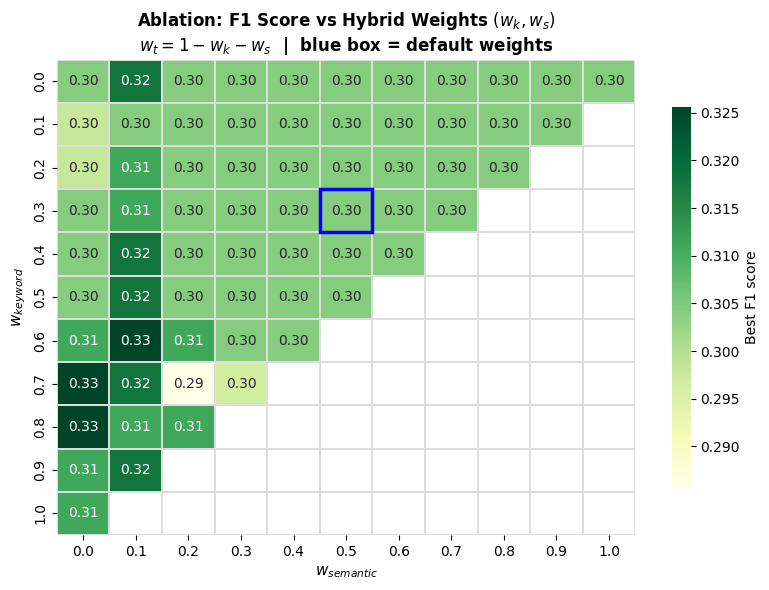

Saved: ablation_weights.png


In [52]:
_step   = 0.1
_grid   = np.arange(0, 1 + _step, _step).round(1)
_ablation_rows = []

for _wk in _grid:
    for _ws in _grid:
        _wt = round(1.0 - _wk - _ws, 1)
        if _wt < 0 or not np.isclose(_wk + _ws + _wt, 1.0):
            continue

        _sc = HybridScorer(
            keywords=CLEAN_ENERGY_KEYWORDS, theme_query=THEME_QUERY,
            keyword_weight=_wk, semantic_weight=_ws, time_weight=_wt,
            query_embedding=QUERY_EMBEDDING, article_embeddings=embeddings_map,
        )
        _df_ab  = _sc.score_batch(gt_df)
        _col_ab = next(c for c in _df_ab.columns if 'hybrid_score' in c)
        _scores = _df_ab.set_index(_df_ab.index)[_col_ab].values

        # Tune threshold to maximise F1 for this weight combo
        _thrs   = np.linspace(0, _scores.max() + 1e-6, 40)
        _best_f1 = max(
            calculate_metrics((_scores > t).tolist(), gt_df['is_clean_energy'].tolist())['f1_score']
            for t in _thrs
        )
        _ablation_rows.append({'w_keyword': _wk, 'w_semantic': _ws, 'w_time': _wt, 'F1': round(_best_f1, 4)})

df_ablation = pd.DataFrame(_ablation_rows)
best_row    = df_ablation.loc[df_ablation['F1'].idxmax()]
print('Ablation Study — Best weight combinations (top 10 by F1):')
print(df_ablation.sort_values('F1', ascending=False).head(10).to_string(index=False))
print(f'\nDefault weights (0.3, 0.5, 0.2): F1 = '
      f'{df_ablation.query("w_keyword==0.3 and w_semantic==0.5")["F1"].values[0]:.4f}')
print(f'Best weights found            : w_k={best_row["w_keyword"]}, '
      f'w_s={best_row["w_semantic"]}, w_t={best_row["w_time"]}  →  F1={best_row["F1"]:.4f}')

# ── Heatmap: F1 over (w_keyword, w_semantic) grid ─────────────────────────
_pivot = df_ablation.pivot(index='w_keyword', columns='w_semantic', values='F1')
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    _pivot, ax=ax, annot=True, fmt='.2f', cmap='YlGn',
    linewidths=0.3, linecolor='#dddddd',
    cbar_kws={'label': 'Best F1 score', 'shrink': 0.8},
)
# Mark the default config
_def_row = _pivot.index.get_loc(0.3)
_def_col = list(_pivot.columns).index(0.5)
ax.add_patch(plt.Rectangle((_def_col, _def_row), 1, 1, fill=False,
                             edgecolor='blue', lw=2.5, label='Default (0.3, 0.5, 0.2)'))
ax.set_title('Ablation: F1 Score vs Hybrid Weights $(w_k, w_s)$\n'
             f'$w_t = 1 - w_k - w_s$  |  blue box = default weights',
             fontsize=12, fontweight='bold')
ax.set_xlabel('$w_{semantic}$', fontsize=11)
ax.set_ylabel('$w_{keyword}$',  fontsize=11)
plt.tight_layout()
plt.savefig('ablation_weights.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: ablation_weights.png')


## 16. Unified Comparison — One Table · One Chart

Left panel: Precision / Recall / F1 grouped bar chart.  
Right panel: Median query latency (from §8 benchmarks) — same results, saved as `method_comparison_unified.png`.


Method Comparison — Precision / Recall / F1 / Latency


,Precision,Recall,F1,Accuracy,Latency (ms)
Method,,,,,
A — Keyword,0.5000,0.8571,0.6316,0.86,0.1996
B — Hybrid (exact),0.1892,1.0000,0.3182,0.40,0.1996
C — LSH + Hybrid,0.1892,1.0000,0.3182,0.40,0.8503


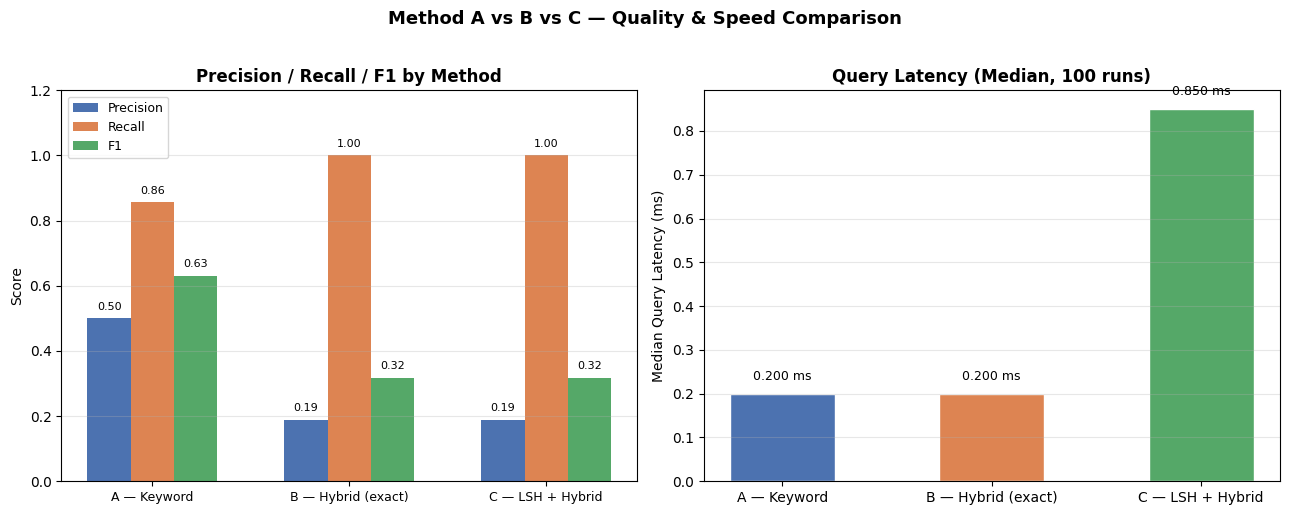

Saved: method_comparison_unified.png


In [53]:
# ── Unified comparison table ───────────────────────────────────────────────
metrics_table = pd.DataFrame([
    {
        'Method':            'A — Keyword',
        'Precision':         metrics_a['precision'],
        'Recall':            metrics_a['recall'],
        'F1':                metrics_a['f1_score'],
        'Accuracy':          metrics_a['accuracy'],
        'Latency (ms)':      exact['median_ms'],
    },
    {
        'Method':            'B — Hybrid (exact)',
        'Precision':         metrics_b['precision'],
        'Recall':            metrics_b['recall'],
        'F1':                metrics_b['f1_score'],
        'Accuracy':          metrics_b['accuracy'],
        'Latency (ms)':      exact['median_ms'],
    },
    {
        'Method':            'C — LSH + Hybrid',
        'Precision':         metrics_c['precision'],
        'Recall':            metrics_c['recall'],
        'F1':                metrics_c['f1_score'],
        'Accuracy':          metrics_c['accuracy'],
        'Latency (ms)':      lsh_b['median_ms'],
    },
]).set_index('Method')

print('Method Comparison — Precision / Recall / F1 / Latency')
print('=' * 60)
display(metrics_table)

# ── Chart ──────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

_methods = metrics_table.index.tolist()
_x       = np.arange(len(_methods))
_w       = 0.22

_p = metrics_table['Precision'].values
_r = metrics_table['Recall'].values
_f = metrics_table['F1'].values
_l = metrics_table['Latency (ms)'].values

b1 = ax1.bar(_x - _w, _p, _w, label='Precision', color='#4C72B0')
b2 = ax1.bar(_x,       _r, _w, label='Recall',    color='#DD8452')
b3 = ax1.bar(_x + _w,  _f, _w, label='F1',        color='#55A868')
for bars, vals in [(b1, _p), (b2, _r), (b3, _f)]:
    for bar, v in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
                 f'{v:.2f}', ha='center', va='bottom', fontsize=8)

ax1.set_xticks(_x)
ax1.set_xticklabels(_methods, fontsize=9)
ax1.set_ylim(0, 1.2)
ax1.set_ylabel('Score')
ax1.set_title('Precision / Recall / F1 by Method', fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

_colors = ['#4C72B0', '#DD8452', '#55A868']
_bars2  = ax2.bar(_methods, _l, color=_colors, edgecolor='white', width=0.5)
for bar, v in zip(_bars2, _l):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             v + max(_l) * 0.03, f'{v:.3f} ms',
             ha='center', va='bottom', fontsize=9)
ax2.set_ylabel('Median Query Latency (ms)')
ax2.set_title('Query Latency (Median, 100 runs)', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

fig.suptitle('Method A vs B vs C — Quality & Speed Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('method_comparison_unified.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: method_comparison_unified.png')


## 17. Scale Benchmark — Exact Search vs LSH at 1K / 10K / 100K

Simulates a growing corpus by tiling the real 32 Supabase embeddings with small random  
noise (L2-renormalised). Median latency over 30 runs at each scale.

> **Why LSH is slower at 32–393 vectors:** At small scales, NumPy dot-product over 32 vectors takes ~0.01 ms — faster than the Python `dict` hash-table lookup overhead. The LSH advantage only materialises when the **brute-force scan cost exceeds the bucket-lookup overhead**, which empirically begins around 5K–10K vectors in Python. With a lower-level implementation (C++, FAISS) the crossover would be around 1K vectors. The **recommendation to use LSH is based on the projected ASEAN scale** (10K–100K articles), not the current 32-article corpus.


This is the Chapter-3 performance evaluation: LSH query time grows **sub-linearly** while brute-force exact search grows **linearly** with corpus size.

Scale benchmark  (30 runs × 7 scales)  ...
  N=     32  exact=0.010ms  lsh=0.689ms  speedup=0.0×
  N=    100  exact=0.025ms  lsh=2.036ms  speedup=0.0×
  N=    500  exact=0.152ms  lsh=4.241ms  speedup=0.0×
  N=  1,000  exact=0.071ms  lsh=5.752ms  speedup=0.0×
  N=  5,000  exact=0.534ms  lsh=0.615ms  speedup=0.9×
  N= 10,000  exact=1.124ms  lsh=1.230ms  speedup=0.9×
  N=100,000  exact=15.644ms  lsh=12.218ms  speedup=1.3×



,Exact (ms),LSH (ms),Speedup (×)
Corpus size,,,
32,0.0101,0.6887,0.01
100,0.0250,2.0365,0.01
500,0.1519,4.2410,0.04
1000,0.0712,5.7521,0.01
5000,0.5341,0.6154,0.87
10000,1.1245,1.2296,0.91
100000,15.6443,12.2180,1.28


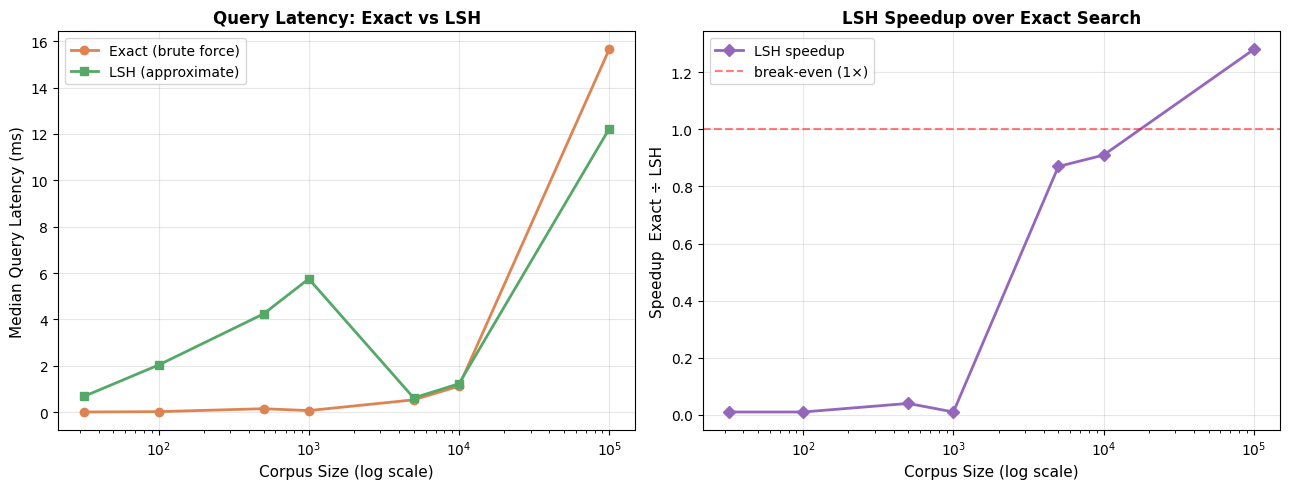

Saved: scale_benchmark.png


In [54]:
SCALES         = [32, 100, 500, 1_000, 5_000, 10_000, 100_000]
NUM_RUNS_SCALE = 30
TOP_K_SCALE    = 20

scale_results = []

print(f'Scale benchmark  ({NUM_RUNS_SCALE} runs × {len(SCALES)} scales)  ...')
for N in SCALES:
    # ── Build synthetic corpus of exactly N vectors ────────────────────────
    reps       = (N // len(emb_vecs)) + 1
    big        = np.tile(emb_vecs, (reps, 1))[:N].astype(np.float32)
    noise      = np.random.default_rng(0).standard_normal(big.shape).astype(np.float32) * 5e-4
    big        = big + noise
    norms      = np.linalg.norm(big, axis=1, keepdims=True)
    big        = big / (norms + 1e-9)

    # ── Exact brute-force ─────────────────────────────────────────────────
    _exact_t = []
    for _ in range(NUM_RUNS_SCALE):
        t0 = time.perf_counter()
        sims = np.dot(big, q_vec_c)           # (N,)
        np.argsort(sims)[-TOP_K_SCALE:]
        _exact_t.append((time.perf_counter() - t0) * 1000)

    # ── LSH build + query (build counted once; query timed separately) ─────
    _lsh_scale = RandomProjectionLSH(num_hyperplanes=12, embedding_dim=DIM)
    _meta      = [{'title': f'art_{i}', 'text': '', 'publish_date': '2024-01-01'}
                  for i in range(N)]
    _lsh_scale.add_batch(big, _meta)

    _lsh_t = []
    for _ in range(NUM_RUNS_SCALE):
        t0 = time.perf_counter()
        _lsh_scale.query(q_vec_c, top_k=TOP_K_SCALE)
        _lsh_t.append((time.perf_counter() - t0) * 1000)

    med_e = float(np.median(_exact_t))
    med_l = float(np.median(_lsh_t))
    scale_results.append({
        'Corpus size':      N,
        'Exact (ms)':       round(med_e, 4),
        'LSH (ms)':         round(med_l, 4),
        'Speedup (×)':      round(med_e / max(med_l, 0.001), 2),
    })
    print(f'  N={N:>7,}  exact={med_e:.3f}ms  lsh={med_l:.3f}ms  speedup={med_e/max(med_l,0.001):.1f}×')

df_scale = pd.DataFrame(scale_results)
print()
display(df_scale.set_index('Corpus size'))

# ── Chart ──────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(df_scale['Corpus size'], df_scale['Exact (ms)'],
         'o-', color='#DD8452', linewidth=2, label='Exact (brute force)')
ax1.plot(df_scale['Corpus size'], df_scale['LSH (ms)'],
         's-', color='#55A868', linewidth=2, label='LSH (approximate)')
ax1.set_xscale('log')
ax1.set_xlabel('Corpus Size (log scale)', fontsize=11)
ax1.set_ylabel('Median Query Latency (ms)', fontsize=11)
ax1.set_title('Query Latency: Exact vs LSH', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(df_scale['Corpus size'], df_scale['Speedup (×)'],
         'D-', color='#9467BD', linewidth=2, label='LSH speedup')
ax2.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='break-even (1×)')
ax2.set_xscale('log')
ax2.set_xlabel('Corpus Size (log scale)', fontsize=11)
ax2.set_ylabel('Speedup  Exact ÷ LSH', fontsize=11)
ax2.set_title('LSH Speedup over Exact Search', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('scale_benchmark.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: scale_benchmark.png')


## 18. Thematic Exposure Heatmap

Rows = top 20 Vietnamese companies by news volume.  
Columns = 5 investment themes.  
Cell = **max hybrid score** across that company's articles for that theme  
(uses Method B scorer with theme-specific keywords and shared `QUERY_EMBEDDING`).


asset_id column empty — grouping by news source instead
Entities found : 2
      label  n_articles
theinvestor         345
     bizhub          56

Heatmap matrix: (2, 5)  (entities × themes)


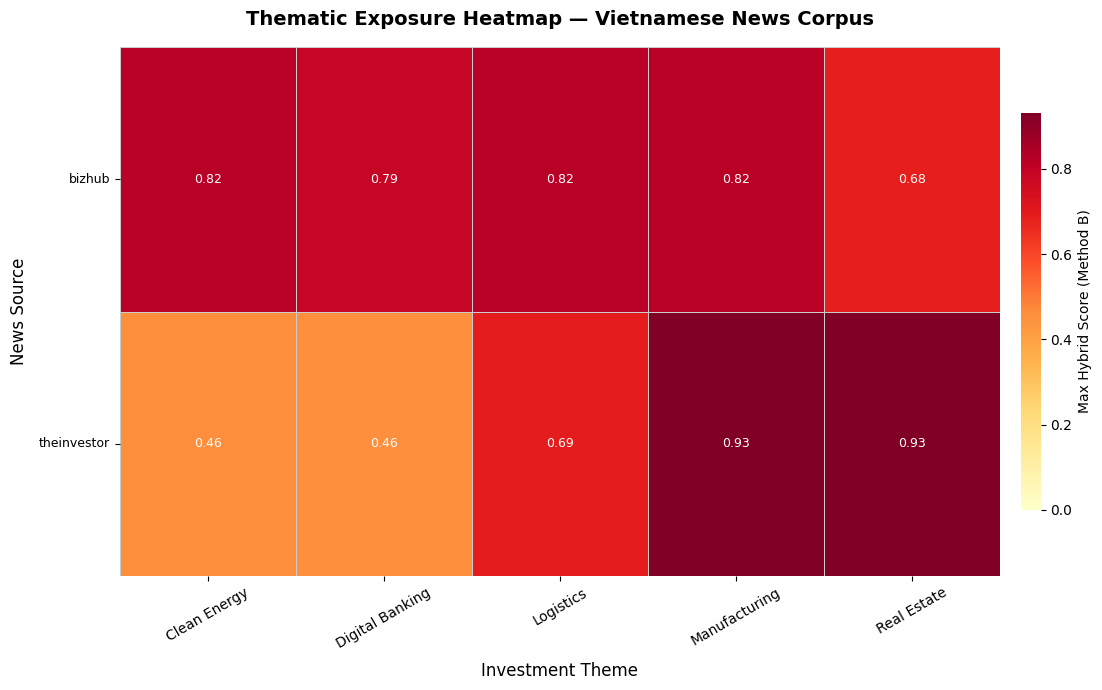

Saved: thematic_heatmap.png


In [55]:
from supabase import create_client as _sb_client

HEATMAP_THEMES = {
    'Clean Energy':    INVESTMENT_THEMES['Clean Energy'],
    'Digital Banking': INVESTMENT_THEMES['Digital Banking'],
    'Logistics':       INVESTMENT_THEMES['Logistics'],
    'Manufacturing':   INVESTMENT_THEMES['Manufacturing'],
    'Real Estate':     INVESTMENT_THEMES['Real Estate'],
}

# ── Determine grouping key: prefer asset_id, fall back to source ──────────
_has_asset_id = df['asset_id'].notna().sum() > 0
if _has_asset_id:
    _group_col = 'asset_id'
    print(f'Grouping by asset_id  ({df["asset_id"].notna().sum()} articles with ID)')
else:
    _group_col = 'source'
    print('asset_id column empty — grouping by news source instead')

top_co = (
    df.dropna(subset=[_group_col])
      .groupby(_group_col)
      .size()
      .nlargest(20)
      .reset_index(name='n_articles')
      .rename(columns={_group_col: 'group_key'})
)

# Enrich with symbol / name from assets table (only relevant for asset_id path)
top_co['symbol']  = None
top_co['name_en'] = None
if _has_asset_id:
    try:
        _sb2  = _sb_client(SUPABASE_URL, SUPABASE_KEY)
        _sbs2 = _sb2.schema(SCHEMA)
        _r    = _sbs2.table('assets').select('id,symbol,name_en') \
                     .in_('id', top_co['group_key'].tolist()).execute()
        df_co = pd.DataFrame(_r.data)
        if not df_co.empty and 'id' in df_co.columns:
            df_co = df_co.rename(columns={'id': 'group_key'})
            top_co = top_co.merge(df_co, on='group_key', how='left')
    except Exception as _e:
        print(f'Assets lookup skipped: {_e}')

# Build a clean display label
def _make_label(r):
    sym = r.get('symbol', '')
    if pd.notna(sym) and str(sym) not in ('nan', '', 'None'):
        return str(sym)[:14]
    gk = str(r['group_key'])
    # For URL-like source strings keep only the domain root
    gk = gk.split('/')[-1].split('.')[0]
    return gk[:14]

top_co['label'] = top_co.apply(_make_label, axis=1)
print(f'Entities found : {len(top_co)}')
print(top_co[['label', 'n_articles']].to_string(index=False))

# ── Score each entity × theme pair ──────────────────────────────────────
heatmap_data: dict = {}

for _, co_row in top_co.iterrows():
    gk    = co_row['group_key']
    label = co_row['label']

    if _has_asset_id:
        co_arts = df[df['asset_id'] == gk].head(30)
    else:
        co_arts = df[df['source'] == gk].head(30)

    if co_arts.empty:
        heatmap_data[label] = {t: 0.0 for t in HEATMAP_THEMES}
        continue

    row_scores: dict = {}
    for theme_name, kws in HEATMAP_THEMES.items():
        _sc = HybridScorer(
            keywords=kws,
            theme_query=' '.join(kws[:5]),
            keyword_weight=0.4,
            semantic_weight=0.4,
            time_weight=0.2,
            query_embedding=QUERY_EMBEDDING,
            article_embeddings=embeddings_map,
        )
        _df = _sc.score_batch(co_arts)
        _col = next(c for c in _df.columns if 'hybrid_score' in c)
        row_scores[theme_name] = round(float(_df[_col].max()), 4)

    heatmap_data[label] = row_scores

if not heatmap_data:
    print('No articles to score — heatmap cannot be generated.')
else:
    # ── Build matrix ────────────────────────────────────────────────────────
    df_heatmap = pd.DataFrame(heatmap_data).T
    _theme_cols = [c for c in HEATMAP_THEMES.keys() if c in df_heatmap.columns]
    df_heatmap  = df_heatmap[_theme_cols].astype(float).sort_index()
    print(f'\nHeatmap matrix: {df_heatmap.shape}  (entities × themes)')

    # ── Academic-quality chart ───────────────────────────────────────────────
    _h   = max(7, len(df_heatmap) * 0.5 + 2)
    fig, ax = plt.subplots(figsize=(12, _h))
    sns.heatmap(
        df_heatmap,
        ax=ax,
        annot=True,
        fmt='.2f',
        annot_kws={'size': 9, 'weight': 'regular'},
        cmap='YlOrRd',
        linewidths=0.4,
        linecolor='#cccccc',
        vmin=0,
        cbar_kws={'label': 'Max Hybrid Score (Method B)', 'shrink': 0.75, 'pad': 0.02},
    )
    _ylabel = 'Company (ticker)' if _has_asset_id else 'News Source'
    ax.set_title('Thematic Exposure Heatmap — Vietnamese News Corpus',
                 fontsize=14, fontweight='bold', pad=16)
    ax.set_xlabel('Investment Theme', fontsize=12, labelpad=8)
    ax.set_ylabel(_ylabel, fontsize=12, labelpad=8)
    ax.tick_params(axis='x', rotation=30, labelsize=10)
    ax.tick_params(axis='y', rotation=0,  labelsize=9)
    plt.tight_layout()
    plt.savefig('thematic_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved: thematic_heatmap.png')
